# RMSD

In [1]:
import matplotlib.pyplot as plt
import numpy as np
def RMSD_100(info: dict, save=False):
    col = info["color"]
    file_path_dic = info["paths"]
    name = info["name"]

    with open(file_path_dic["RMSD_1"]) as RMSD_file:
        RMSD_raw = RMSD_file.readlines()
        time_1 = [float(x.split()[0]) for x in RMSD_raw[18:] ]
        RMSD_1 = [float(x.split()[1][:9]) for x in RMSD_raw[18:] ]
    with open(file_path_dic["RMSD_2"]) as RMSD_file:
        RMSD_raw = RMSD_file.readlines()
        time_2 = [float(x.split()[0]) for x in RMSD_raw[18:] ]
        RMSD_2 = [float(x.split()[1][:9]) for x in RMSD_raw[18:] ]

    # 设置滑动窗口大小
    window_size = 40

    def moving_average(x, w):
        return np.convolve(x, np.ones(w), 'valid') / w

    # 对数据进行滑动平均处理
    RMSD_1_smooth = moving_average(RMSD_1, window_size)
    RMSD_2_smooth = moving_average(RMSD_2, window_size)

    # 由于滑动平均会减少数据点的数量，需要相应地调整x轴数据
    time_1_smooth = time_1[:len(RMSD_1_smooth)]
    time_2_smooth = time_2[:len(RMSD_2_smooth)]

    # 设置曲线向右移动的距离
    shift = 1000  # 你可以根据需要调整这个值

    # 将 x 轴数据向右移动
    time_1_smooth_shifted = [x + shift for x in time_1_smooth]
    time_2_smooth_shifted = [x + shift for x in time_2_smooth]

    alpha = 0.5
    fig, ax2 = plt.subplots(figsize=(8, 2.5))
    ax2.plot(time_1_smooth_shifted, RMSD_1_smooth, linewidth=0.8, label='100 ns (Rep 1)', color = col[0])
    ax2.plot(time_1, RMSD_1, linewidth=1.5, label='', color = col[0], alpha = alpha)

    ax2.plot(time_2_smooth_shifted, RMSD_2_smooth, linewidth=0.8, label='100 ns (Rep 2)', color = col[1])
    ax2.plot(time_2, RMSD_2, linewidth=1.5, label='', color = col[1], alpha = alpha)

    # Hide the right and top spines
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    plt.title('RMSD of Rep 1&2', fontsize=18)
    plt.xlabel('Time (ns)', fontsize=18)
    plt.ylabel('RMSD (nm)', fontsize=18)
    plt.xticks(
        [ x for x in range(0,100001,10000) ],
        ["0","10","20","30","40","50","60","70","80","90","100"],
        fontsize=14)
    plt.yticks(fontsize=14)

    # 设置图形的 DPI
    fig.set_dpi(300)

    # 添加图例
    plt.legend(loc='lower right', frameon=True)

    plt.grid(True,axis="x")
    if save:
        plt.savefig(f"./Pics/RMSD_100_{name}.svg", dpi=300)
        plt.savefig(f"./Pics/RMSD_100_{name}.png", dpi=300)
    plt.show()
    plt.close('all')

def RMSD_500(info: dict, save=False):
    col = info["color"]
    file_path_dic = info["paths"]
    name = info["name"]
    def moving_average(x, w):
        return np.convolve(x, np.ones(w), 'valid') / w

    with open(file_path_dic["RMSD_3"]) as RMSD_file:
        RMSD_raw = RMSD_file.readlines()
        time_1 = [float(x.split()[0]) for x in RMSD_raw[18:] ]
        RMSD_1 = [float(x.split()[1][:9]) for x in RMSD_raw[18:] ]

    # 设置滑动窗口大小
    window_size = 40

    # 对数据进行滑动平均处理
    RMSD_1_smooth = moving_average(RMSD_1, window_size)

    # 由于滑动平均会减少数据点的数量，需要相应地调整x轴数据
    time_1_smooth = time_1[:len(RMSD_1_smooth)]

    # 设置曲线向右移动的距离
    shift = 1000  # 你可以根据需要调整这个值

    # 将 x 轴数据向右移动
    time_1_smooth_shifted = [x + shift for x in time_1_smooth]

    alpha = 0.5
    fig, ax2 = plt.subplots(figsize=(8, 2.5))
    ax2.plot(time_1_smooth_shifted, RMSD_1_smooth, linewidth=0.8, label='500 ns (Rep 3)', color = col[0])
    ax2.plot(time_1, RMSD_1, linewidth=1.5, label='', color = col[0], alpha = alpha)

    # Hide the right and top spines
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    plt.title('RMSD of Rep 3', fontsize=18)
    plt.xlabel('Time (ns)', fontsize=18)
    plt.ylabel('RMSD (nm)', fontsize=18)
    plt.xticks(
        [ x for x in range(0,500001,50000) ],
        ['0', '50', '100', '150', '200', '250', '300', '350', '400', '450', '500'],
        fontsize=14)
    plt.yticks(fontsize=14)

    # 设置图形的 DPI
    fig.set_dpi(300)

    # 添加图例
    plt.legend(loc='lower right', frameon=True)

    plt.grid(True,axis="x")
    if save:
        plt.savefig(f"./Pics/RMSD_500_{name}.svg", dpi=300)
        plt.savefig(f"./Pics/RMSD_500_{name}.png", dpi=300)
    plt.show()
    plt.close('all')

## sys info

In [2]:
PAC5_info_dic = {
    "name": "PAC5",
    "paths" : {
        "RMSD_1": "../PAC5_100_1/4_RMSD/RMSD.xvg",
        "RMSD_2": "../PAC5_100_2/4_RMSD/RMSD.xvg",
        "RMSD_3": "../PAC5_500_3/4_RMSD/RMSD.xvg"
    },
    "color" : ["#2F81B9", "#2FB9A0"]
}
RNA_info_dic = {
    "name": "RNA",
    "paths" : {
        "RMSD_1": "../RNA_100_1/4_RMSD/RMSD.xvg",
        "RMSD_2": "../RNA_100_2/4_RMSD/RMSD.xvg",
        "RMSD_3": "../RNA_500_3/4_RMSD/RMSD.xvg"
    },
    "color" : ["#FF9333", "#FF4733"]
}
ssDNA_info_dic = {
    "name": "ssDNA",
    "paths" : {
        "RMSD_1": "../ssDNA_100_1/4_RMSD/RMSD.xvg",
        "RMSD_2": "../ssDNA_100_2/4_RMSD/RMSD.xvg",
        "RMSD_3": "../ssDNA_500_3/4_RMSD/RMSD.xvg"
    },
    "color" : ["#3AA63A", "#7EA63A"]
}

## PAC5

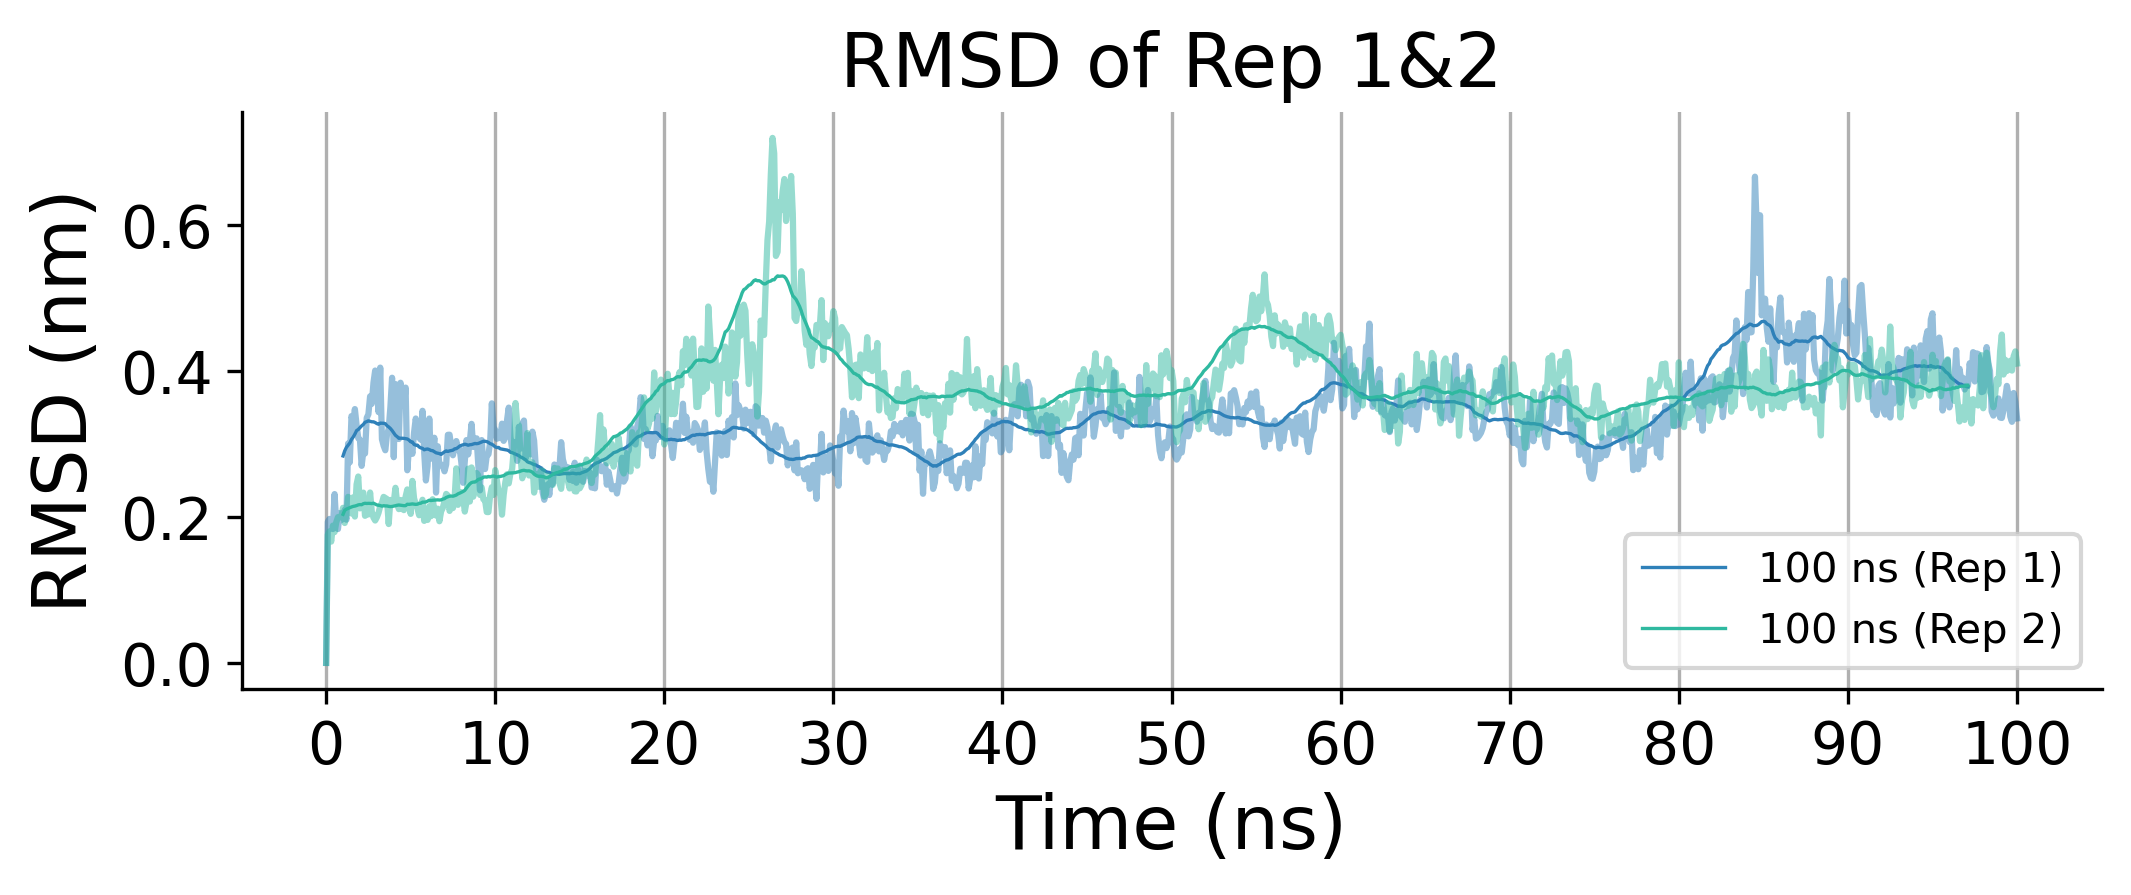

In [3]:
RMSD_100(PAC5_info_dic, save=True)

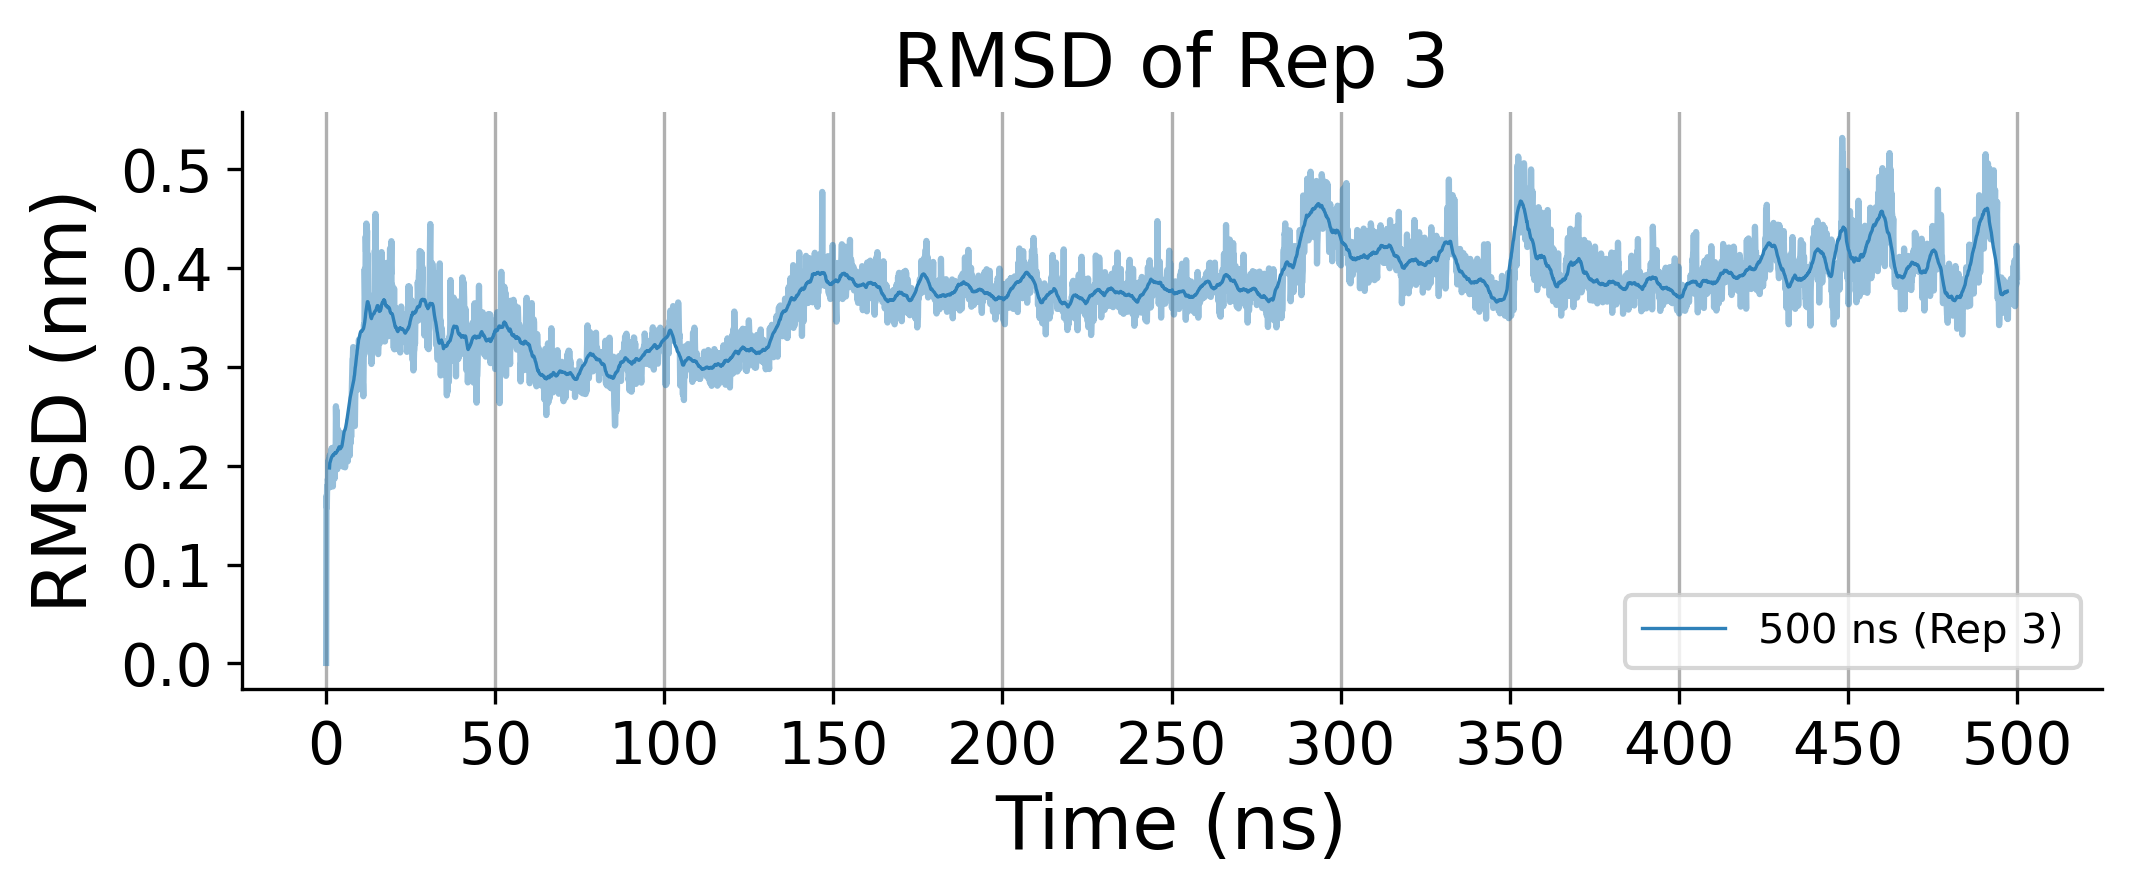

In [4]:
RMSD_500(PAC5_info_dic, save=True)

## RNA

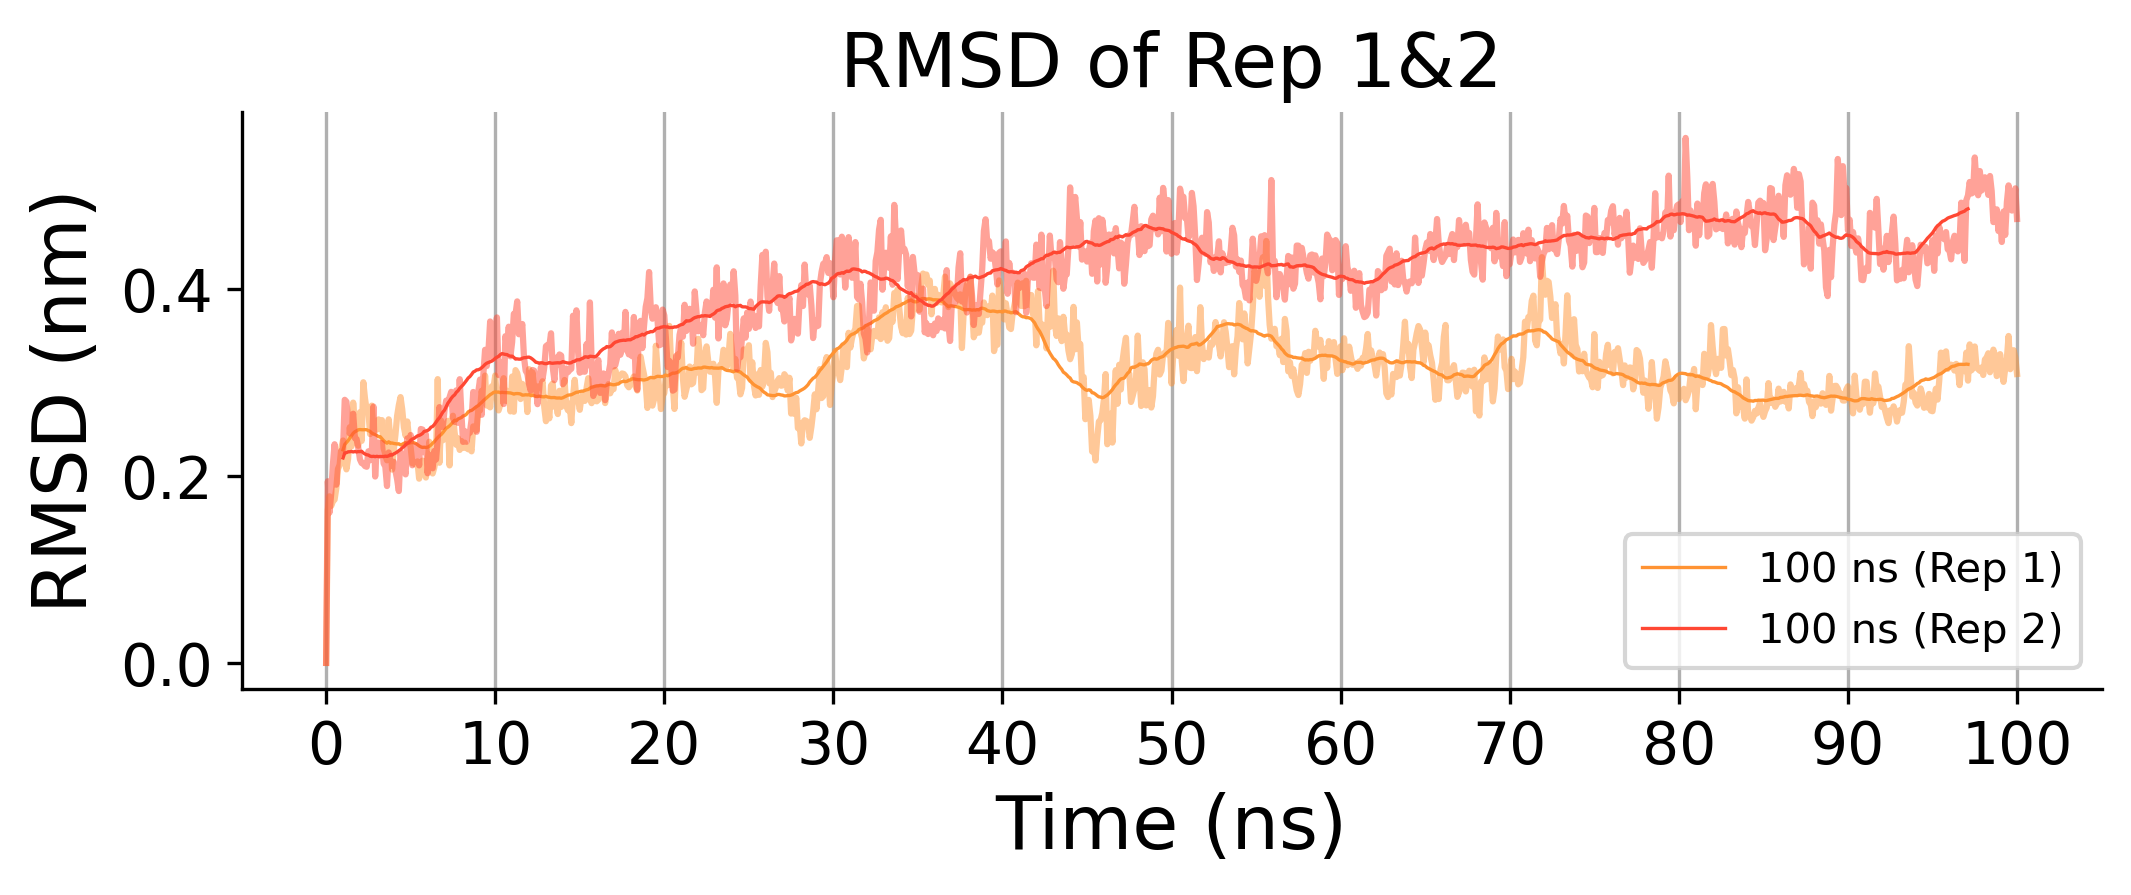

In [5]:
RMSD_100(RNA_info_dic, save=True)

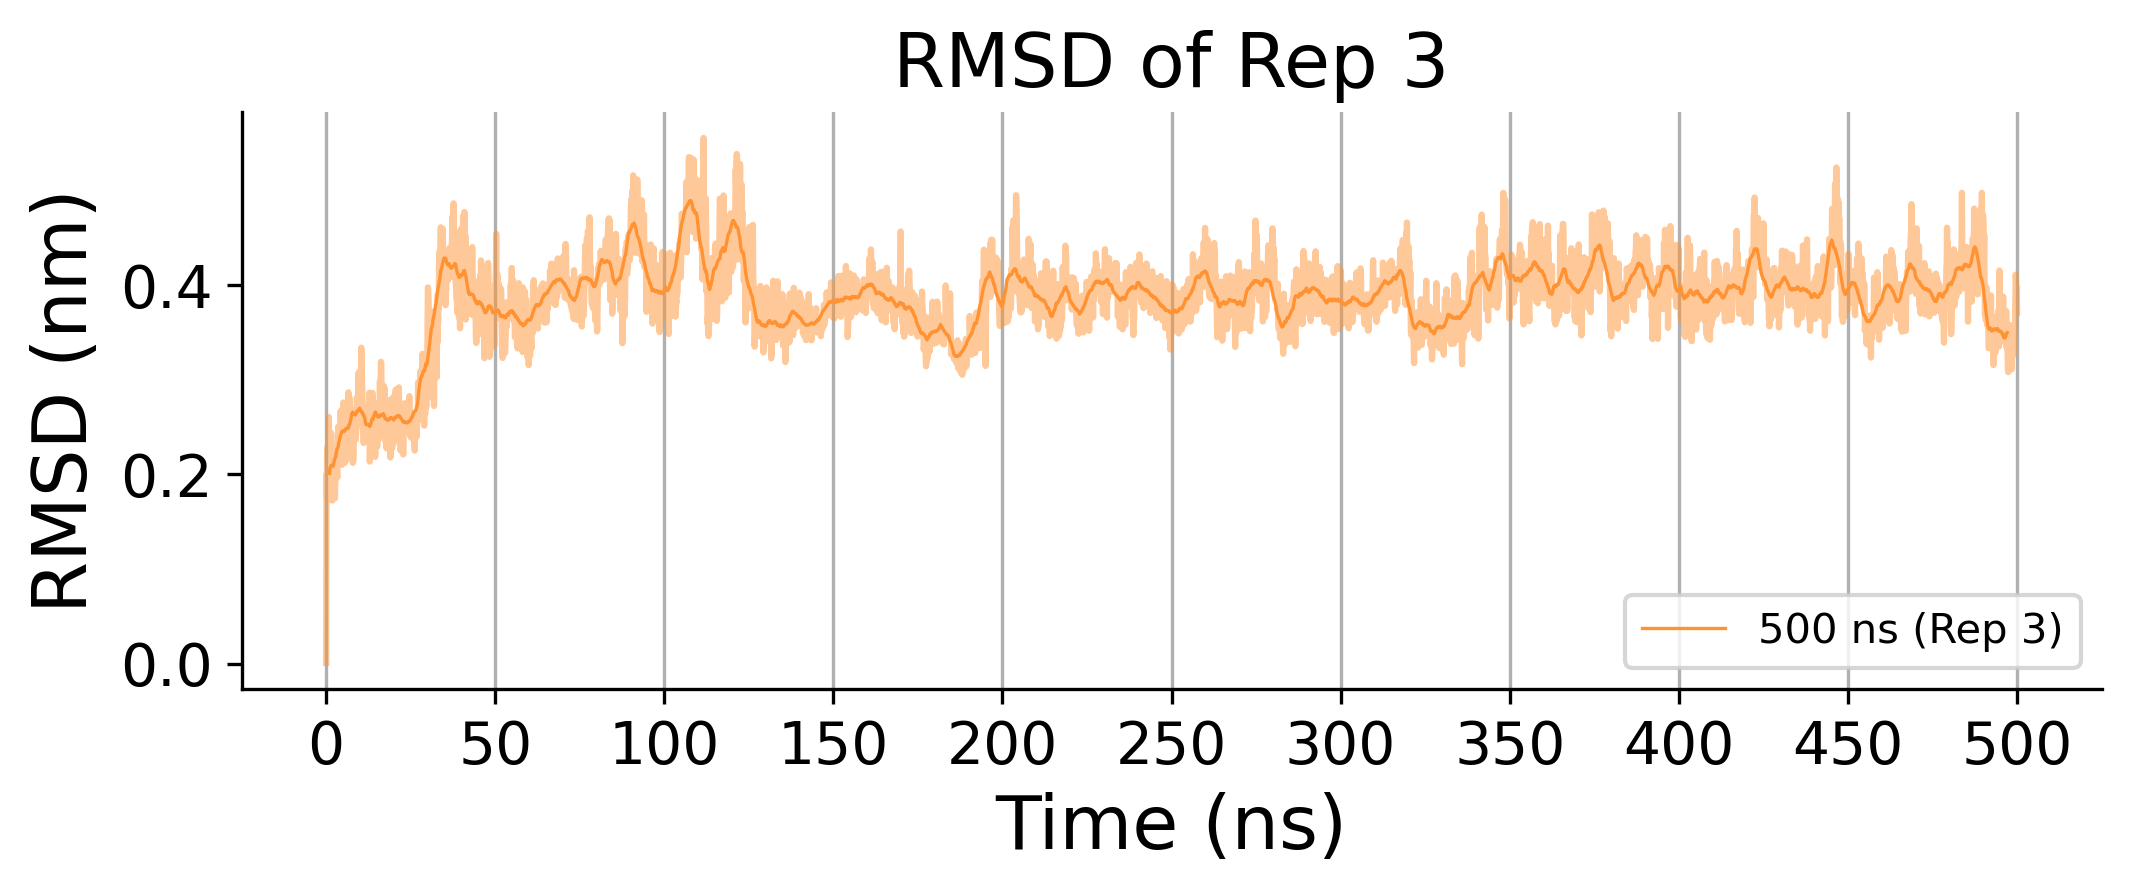

In [6]:
RMSD_500(RNA_info_dic, save=True)

## ssDNA

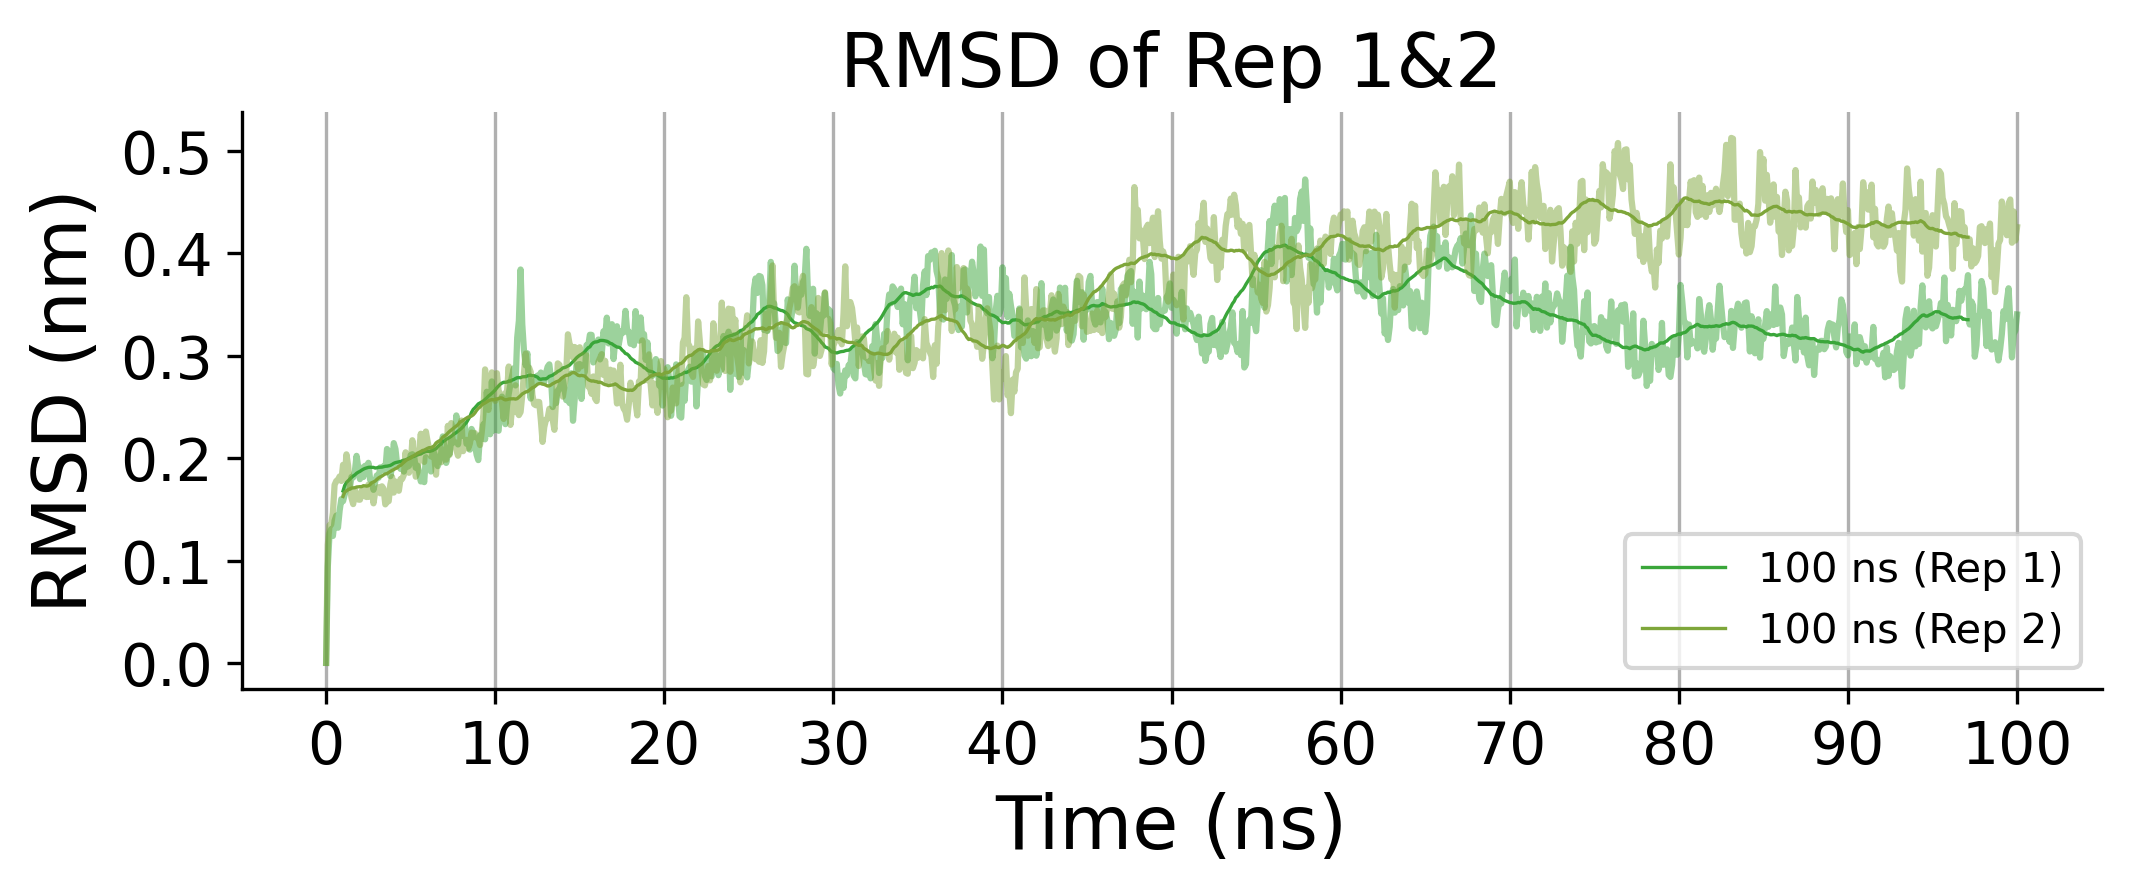

In [7]:
RMSD_100(ssDNA_info_dic, save=True)

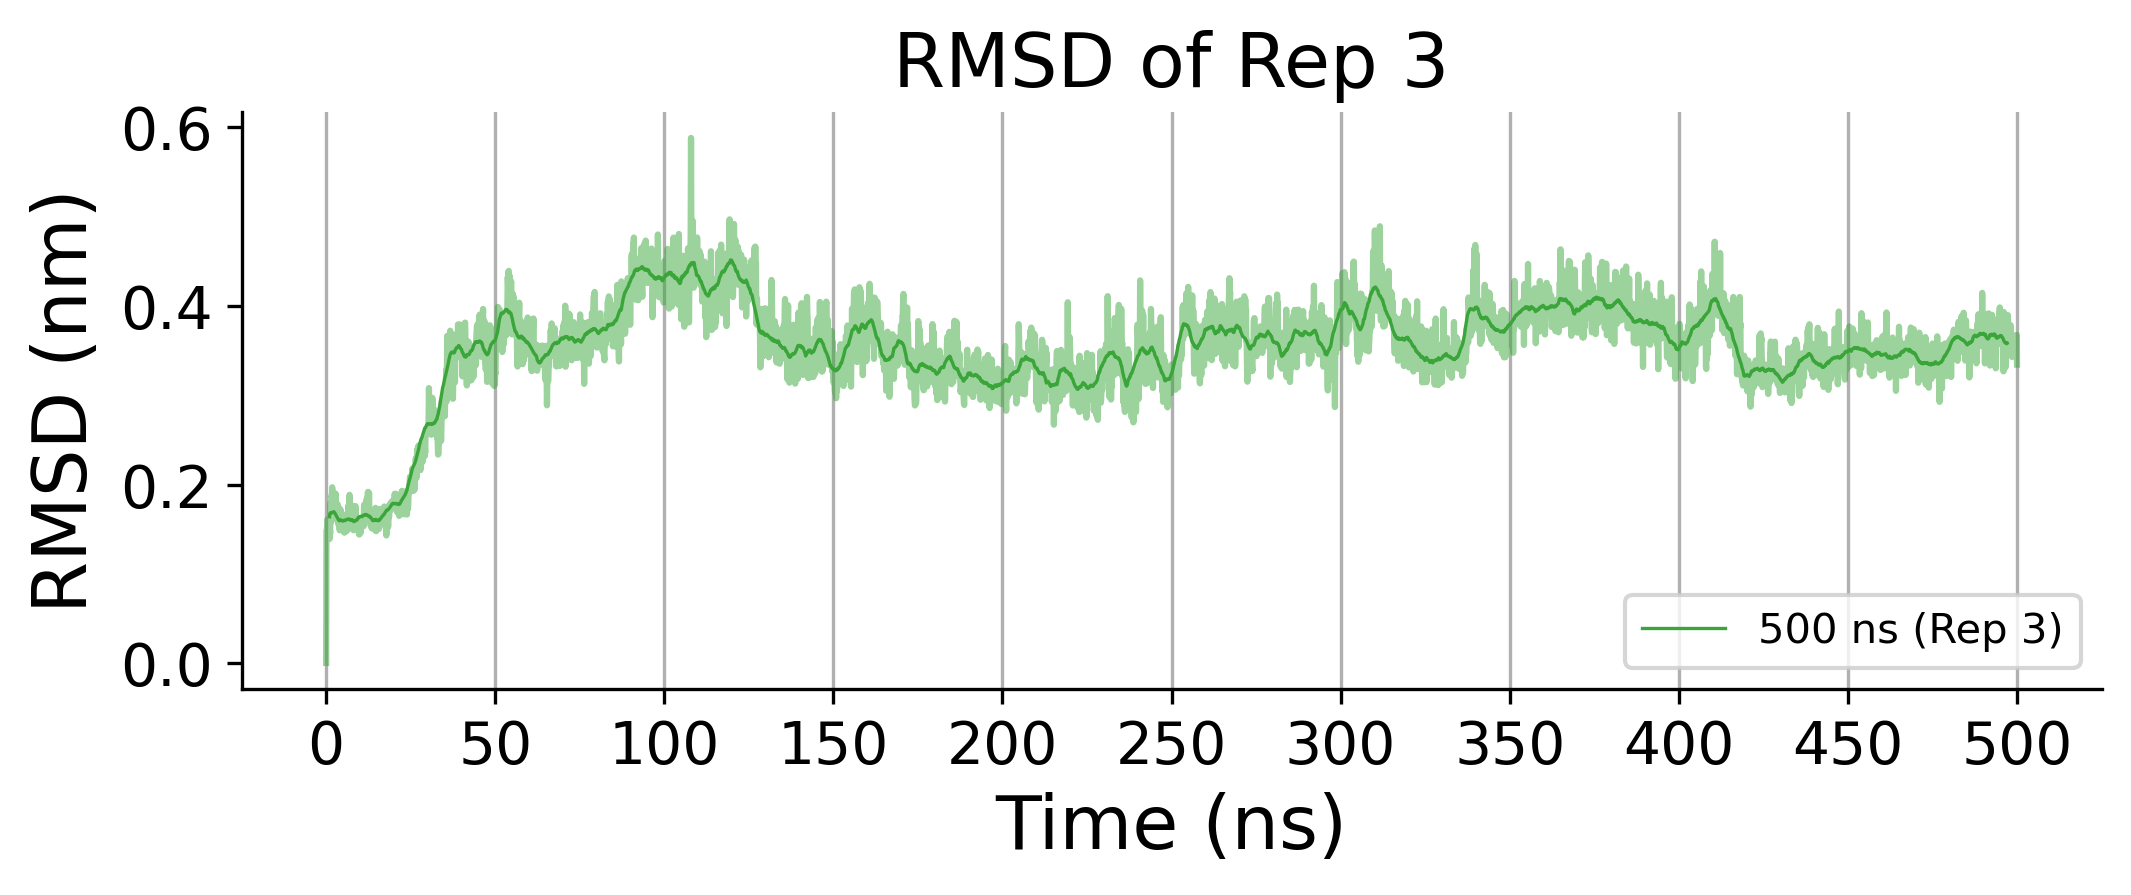

In [8]:
RMSD_500(ssDNA_info_dic, save=True)

# Gyrate

In [9]:
import matplotlib.pyplot as plt
import numpy as np
def Gyrate_100(info: dict, save=False):
    col = info["color"]
    file_path_dic = info["paths"]
    name = info["name"]
    
    with open(file_path_dic["Gyrate_1"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_1 = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_1 = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_2"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_2 = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_2 = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]

    fig, ax2 = plt.subplots(figsize=(8, 2.5))
    ax2.plot(time_1, Gyrate_1, linewidth=1, label='100 ns (Rep 1)', color=col[0])
    ax2.plot(time_2, Gyrate_2, linewidth=1, label='100 ns (Rep 2)', color=col[1])

    # Hide the right and top spines
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    plt.title('Radius of gyration (total axes of Rep 1&2)', fontsize=18)
    plt.xlabel('Time (ns)', fontsize=18)
    plt.ylabel('Rg (nm)', fontsize=18)
    plt.xticks(
        [ x for x in range(0,100001,10000) ],
        ["0","10","20","30","40","50","60","70","80","90","100"],
        fontsize=14
        )
    plt.yticks(fontsize=14)

    # 设置图形的 DPI
    fig.set_dpi(300)

    # 添加图例
    plt.legend(loc='lower right', frameon=True)

    plt.grid(True,axis="x")

    if save:
        plt.savefig(f"./Pics/Gyrate_100_{name}.svg", dpi=300)
        plt.savefig(f"./Pics/Gyrate_100_{name}.png", dpi=300)
    plt.show()
    plt.close('all')


def Gyrate_500(info: dict, save=False):
    file_path_dic = info["paths"]
    name = info["name"]
    
    with open(file_path_dic["Gyrate_3"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_s = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_s = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_3"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_x = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_x = [ float(x.split()[2][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_3"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_y = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_y = [ float(x.split()[3][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_3"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_z = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_z = [ float(x.split()[4][:9]) for x in Gyrate_raw[28:] ]

    fig, ax2 = plt.subplots(figsize=(8, 2.5))
    ax2.plot(time_s, Gyrate_s, linewidth=1, label='Rg')
    ax2.plot(time_z, Gyrate_x, linewidth=1, label='Rg X')
    ax2.plot(time_y, Gyrate_y, linewidth=1, label='Rg Y')
    ax2.plot(time_z, Gyrate_z, linewidth=1, label='Rg Z')

    # Hide the right and top spines
    ax2.spines['right'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    plt.title('Radius of gyration (total and around axes of Rep 3)', fontsize=18)
    plt.xlabel('Time (ns)', fontsize=18)
    plt.ylabel('Rg (nm)', fontsize=18)
    plt.xticks(
        [ x for x in range(0,500001,50000) ],
        ['0', '50', '100', '150', '200', '250', '300', '350', '400', '450', '500'],
        fontsize=14)
    plt.yticks(fontsize=14)

    # 设置图形的 DPI
    fig.set_dpi(300)

    # 添加图例
    plt.legend(loc='lower right', frameon=True)

    plt.grid(True,axis="x")

    if save:
        plt.savefig(f"./Pics/Gyrate_500_{name}.svg", dpi=300)
        plt.savefig(f"./Pics/Gyrate_500_{name}.png", dpi=300)
    plt.show()
    plt.close('all')

## sys info

In [10]:
PAC5_info_dic = {
    "name": "PAC5",
    "paths" : {
        "Gyrate_1": "../PAC5_100_1/6_Gyrate/gyrate.xvg",
        "Gyrate_2": "../PAC5_100_2/6_Gyrate/gyrate.xvg",
        "Gyrate_3": "../PAC5_500_3/6_Gyrate/gyrate.xvg"
    },
    "color" : ["#2F81B9", "#2FB9A0"]
}
RNA_info_dic = {
    "name": "RNA",
    "paths" : {
        "Gyrate_1": "../RNA_100_1/6_Gyrate/gyrate.xvg",
        "Gyrate_2": "../RNA_100_2/6_Gyrate/gyrate.xvg",
        "Gyrate_3": "../RNA_500_3/6_Gyrate/gyrate.xvg"
    },
    "color" : ["#FF9333", "#FF4733"]
}
ssDNA_info_dic = {
    "name": "ssDNA",
    "paths" : {
        "Gyrate_1": "../ssDNA_100_1/6_Gyrate/gyrate.xvg",
        "Gyrate_2": "../ssDNA_100_2/6_Gyrate/gyrate.xvg",
        "Gyrate_3": "../ssDNA_500_3/6_Gyrate/gyrate.xvg"
    },
    "color" : ["#3AA63A", "#7EA63A"]
}

## PAC5

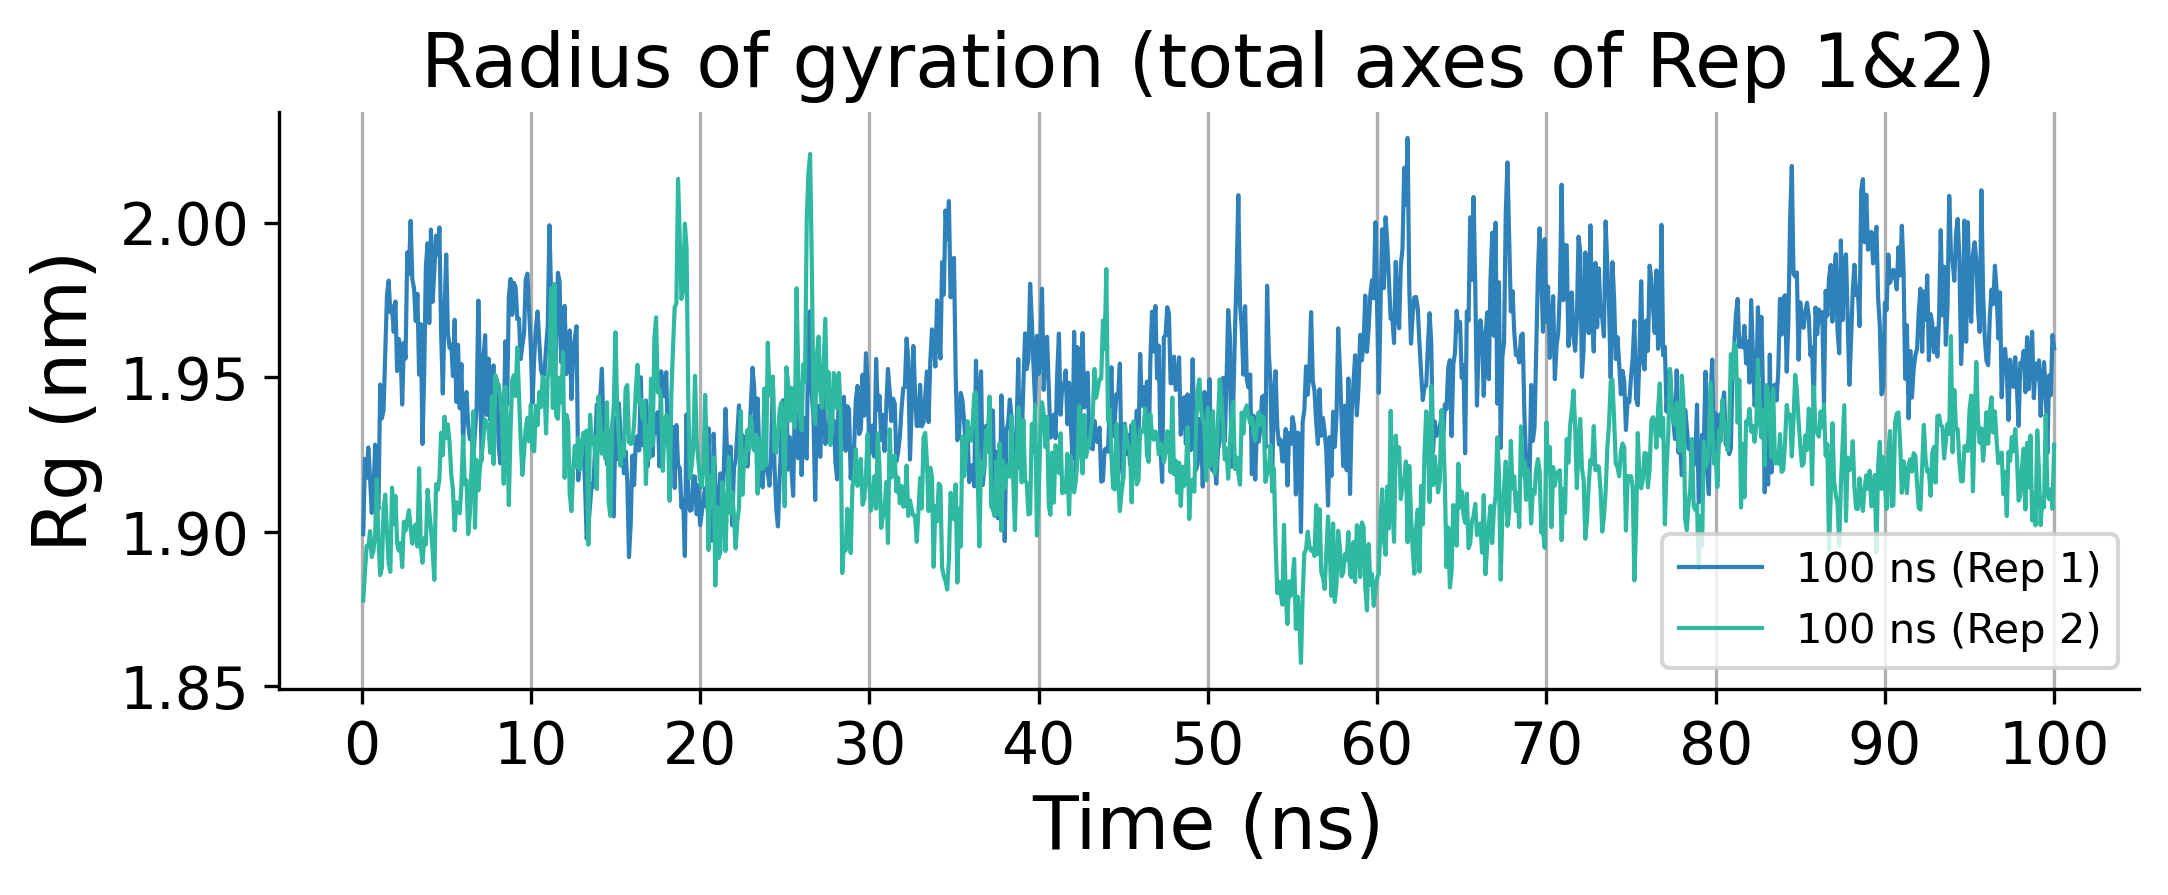

In [11]:
Gyrate_100(PAC5_info_dic, save=True)

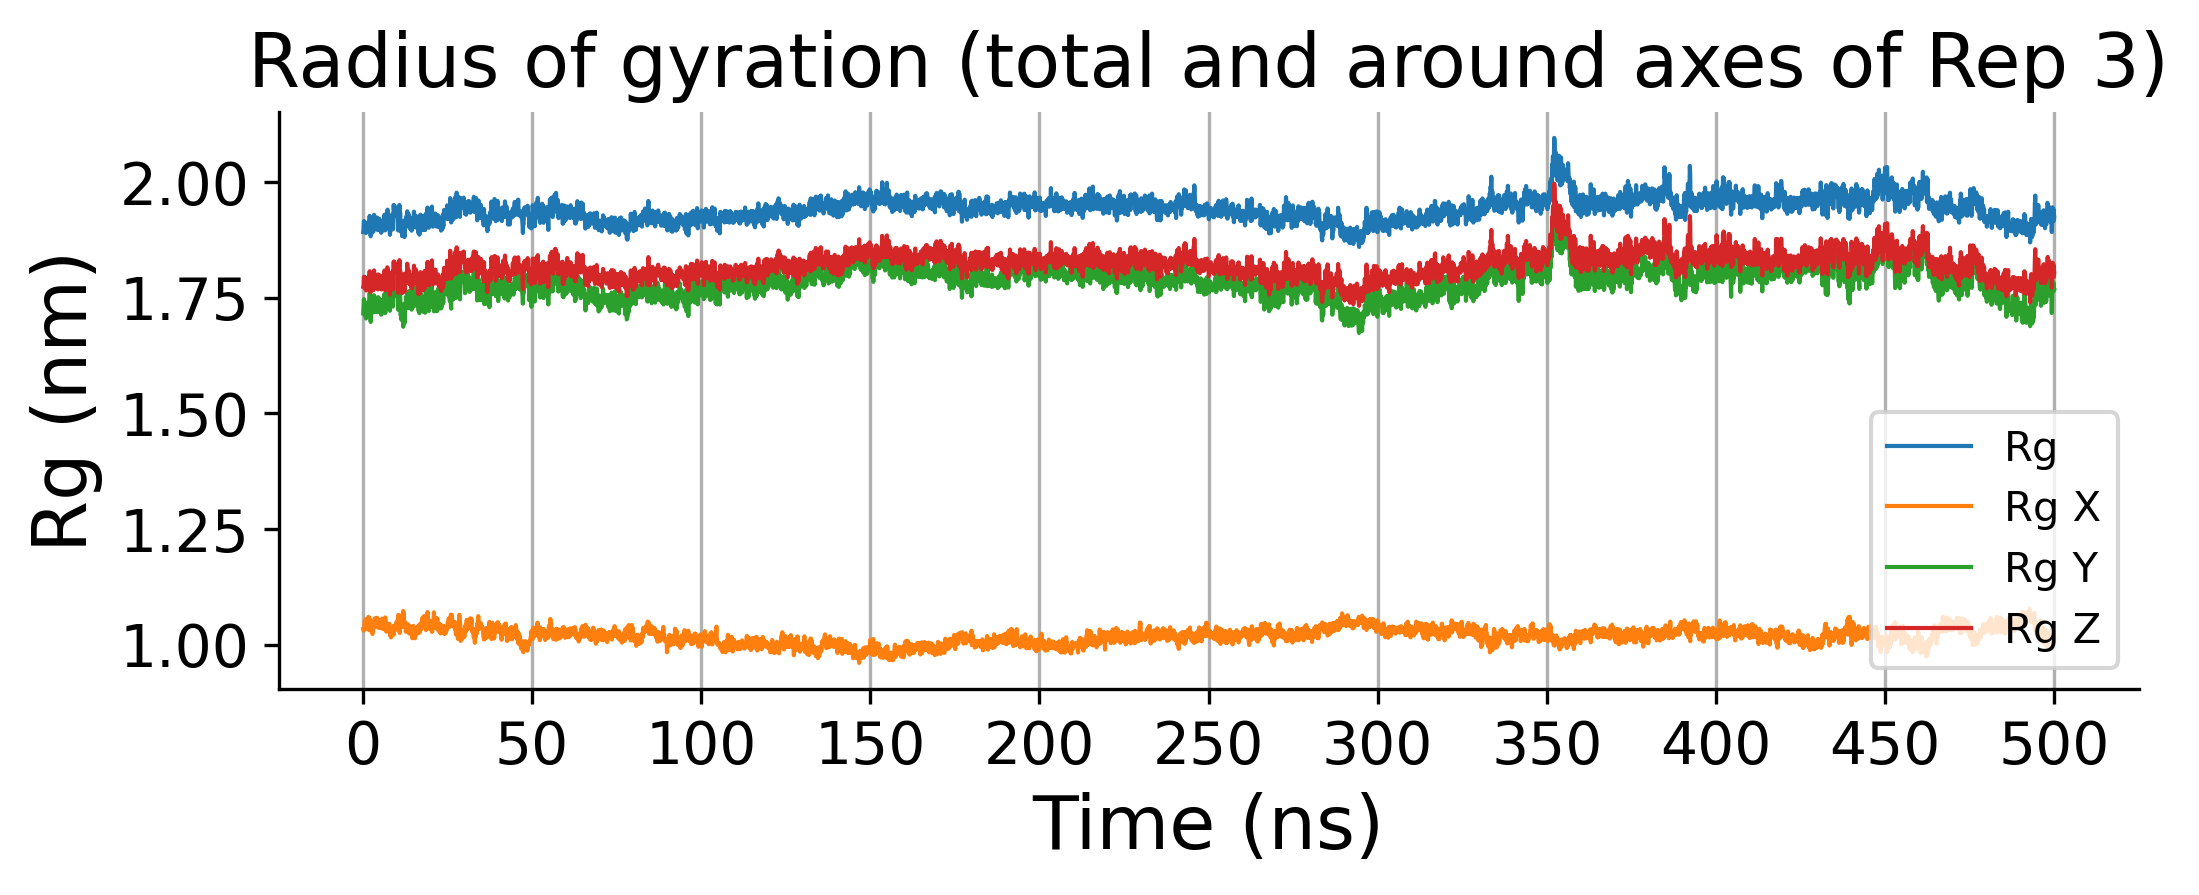

In [12]:
Gyrate_500(PAC5_info_dic, save=True)

## RNA

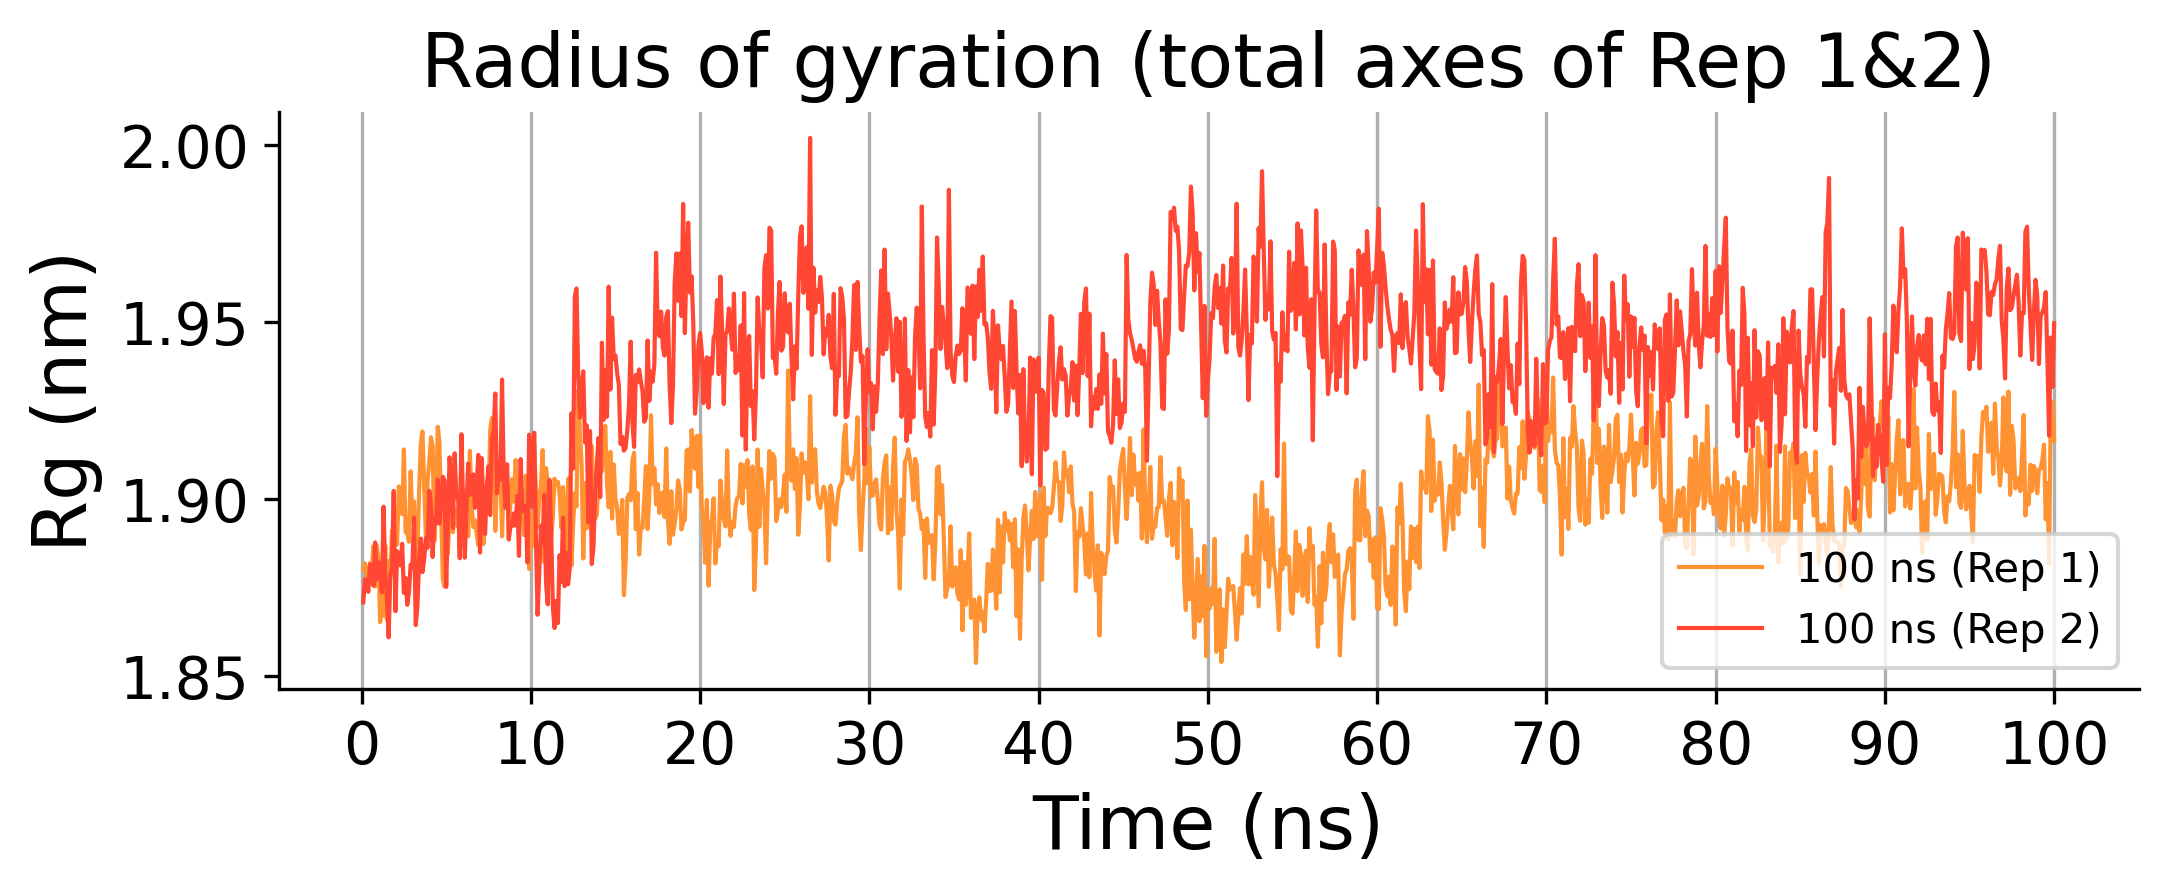

In [13]:
Gyrate_100(RNA_info_dic, save=True)

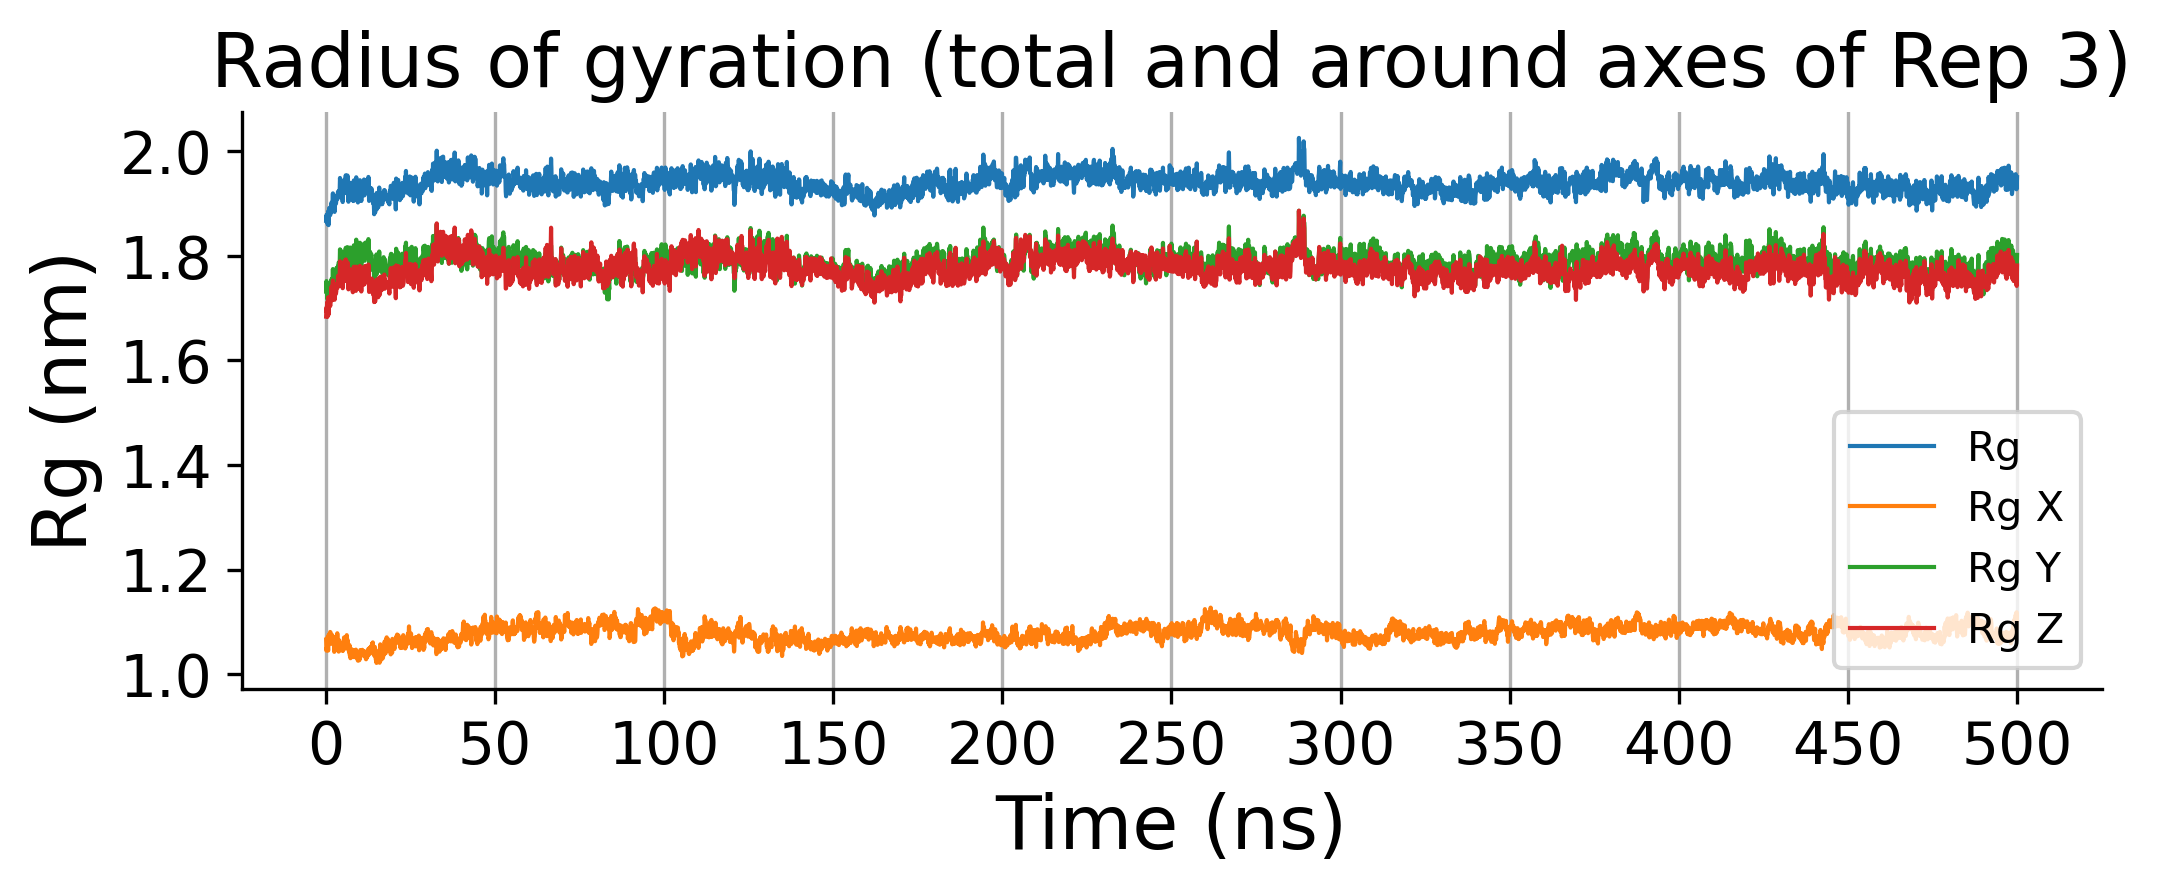

In [14]:
Gyrate_500(RNA_info_dic, save=True)

## ssDNA

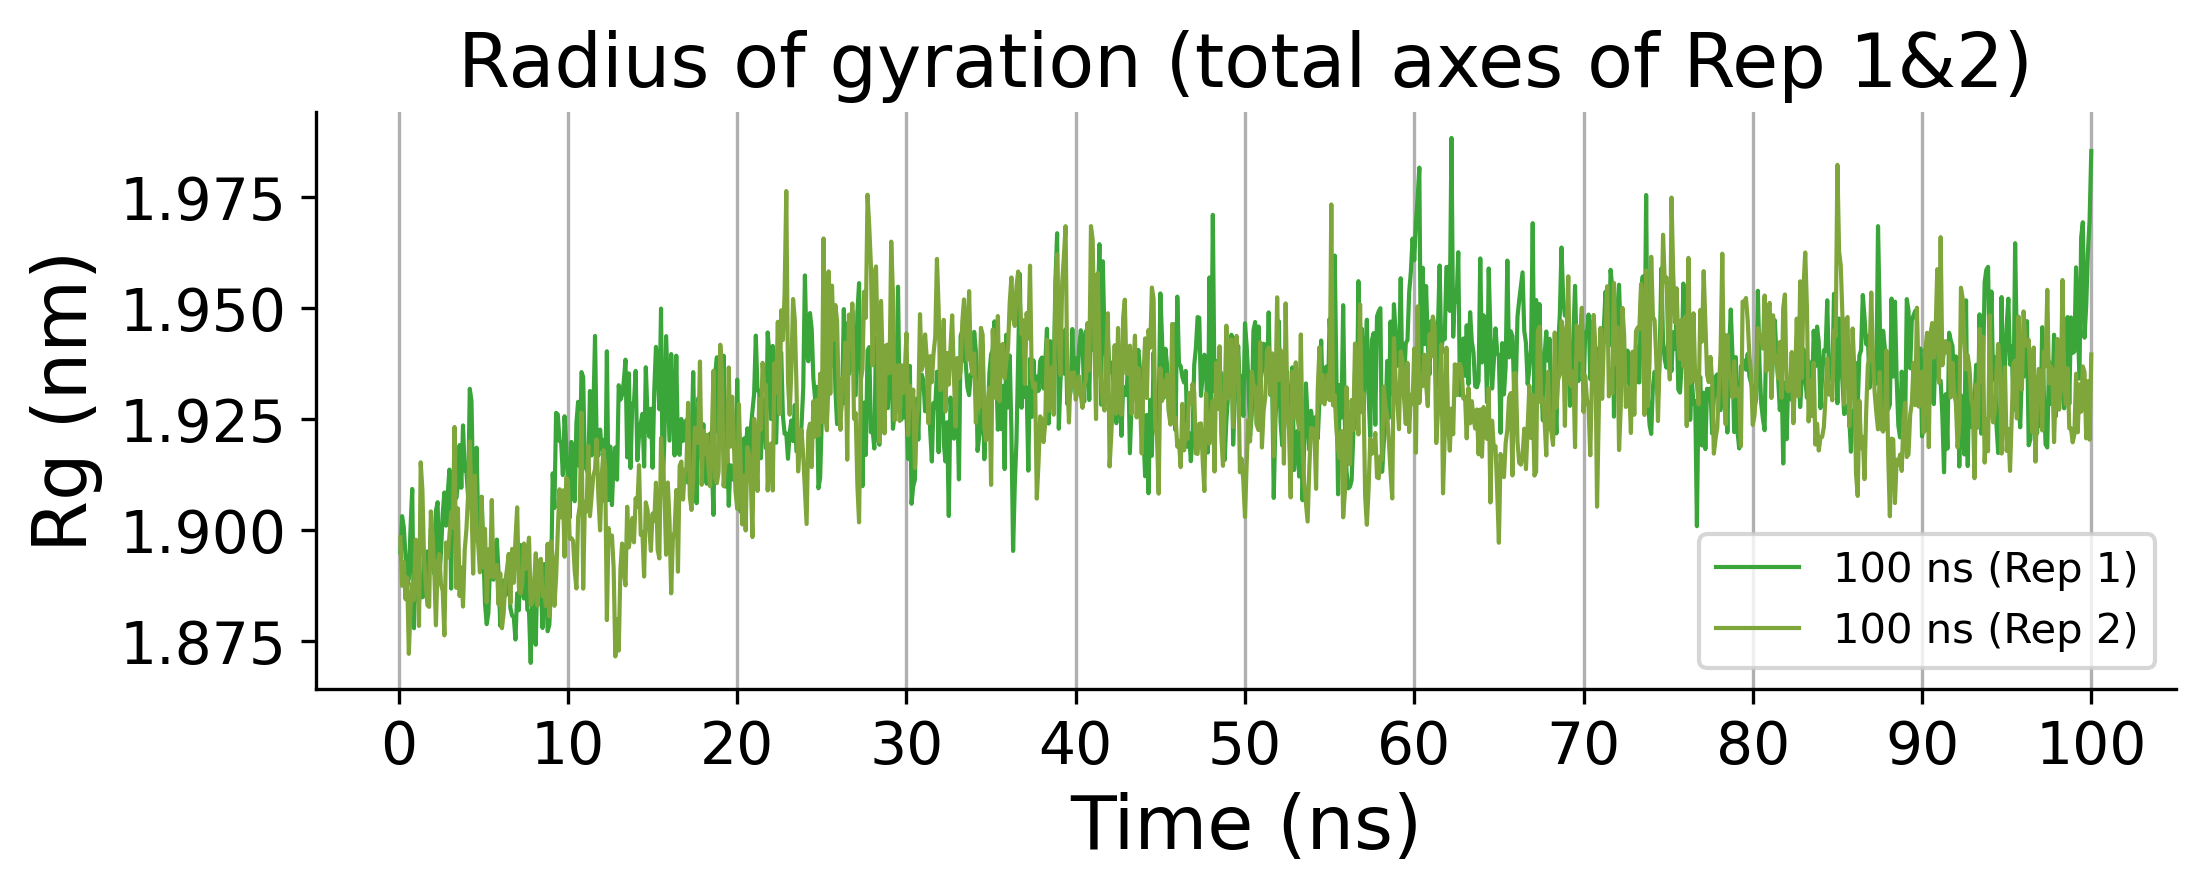

In [15]:
Gyrate_100(ssDNA_info_dic, save=True)

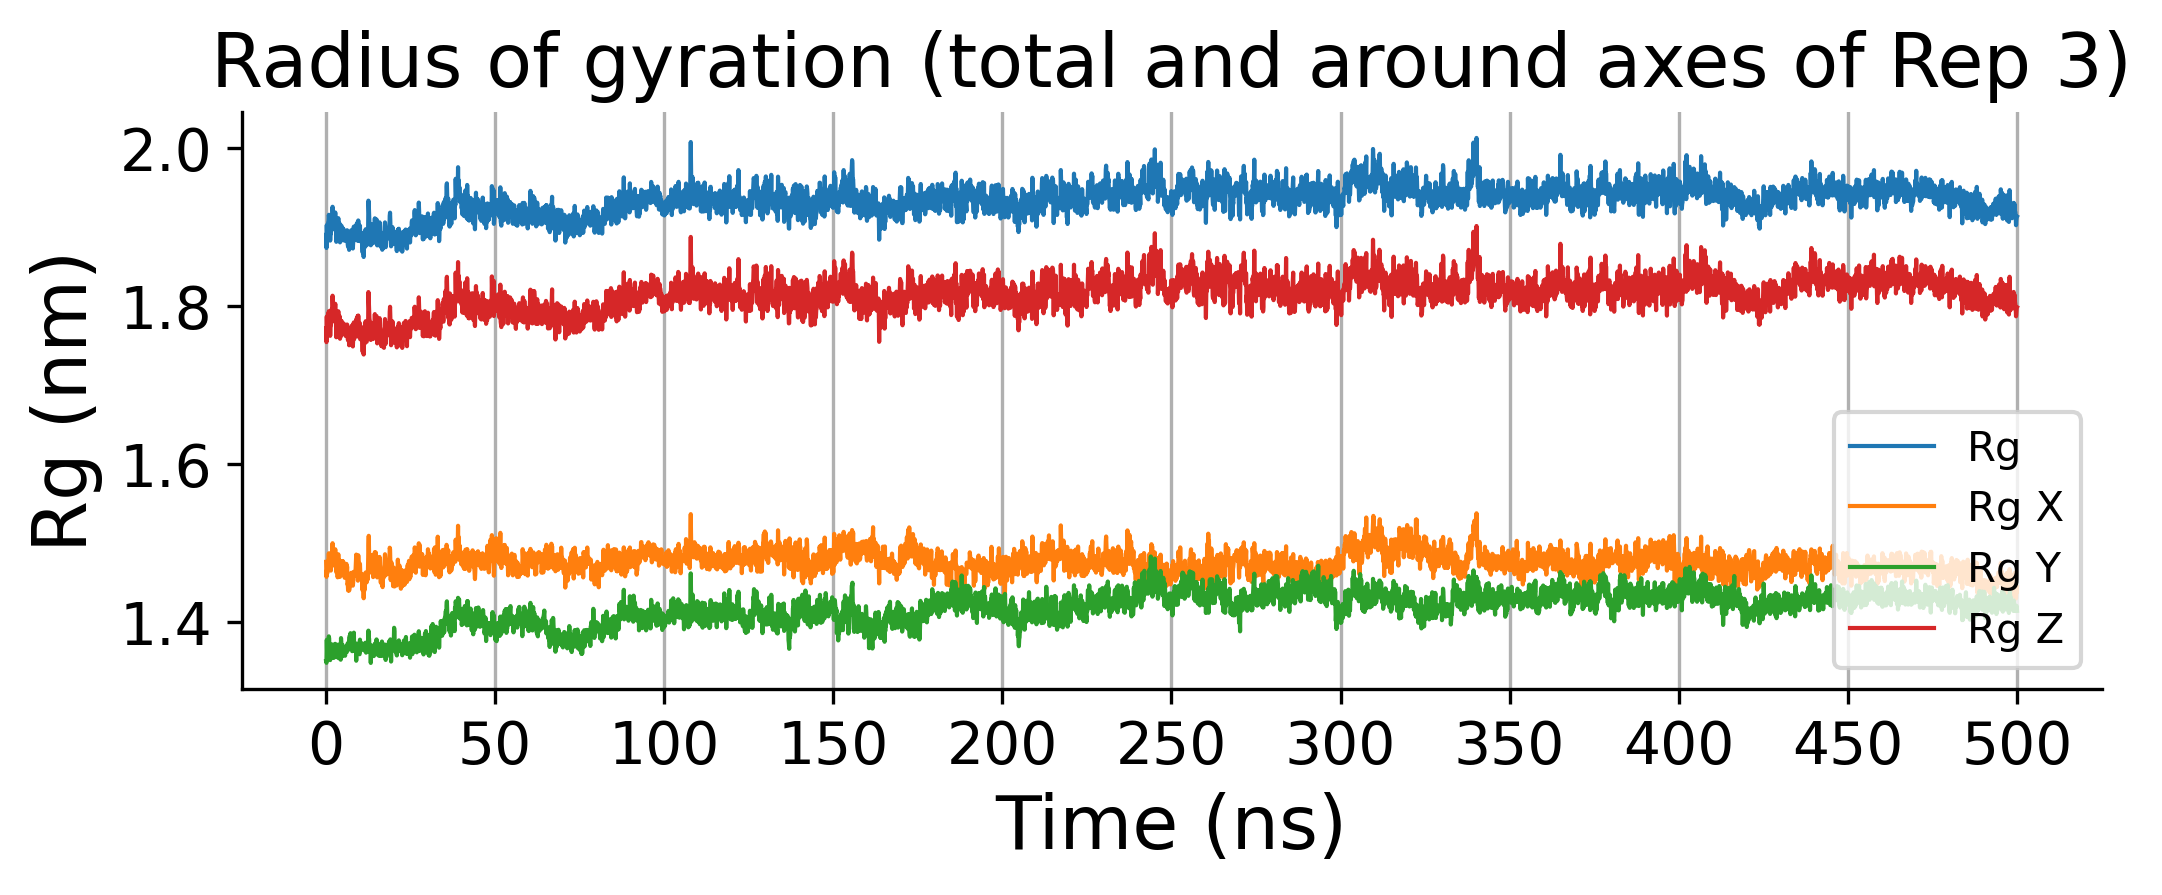

In [16]:
Gyrate_500(ssDNA_info_dic, save=True)

## Violin

In [17]:
import pandas as pd
def Gyrate_violin_df(info: dict):
    col = info["color"]
    file_path_dic = info["paths"]
    name = info["name"]
    
    with open(file_path_dic["Gyrate_1"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_1 = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_1 = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_2"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_2 = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_2 = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]
    with open(file_path_dic["Gyrate_3"]) as Gyrate_file:
        Gyrate_raw = Gyrate_file.readlines()
        time_3 = [ float(x.split()[0]) for x in Gyrate_raw[28:] ]
        Gyrate_3 = [ float(x.split()[1][:9]) for x in Gyrate_raw[28:] ]
    Frame = time_1 + time_2 + time_3
    data  = Gyrate_1 + Gyrate_2 + Gyrate_3
    # print(len(Frame), len(data))
    return pd.DataFrame({
        "Frame"  : Frame,
        str(name): data
    })

In [18]:
Gyrate_dat          = Gyrate_violin_df(PAC5_info_dic)
Gyrate_dat["RNA"]   = Gyrate_violin_df(RNA_info_dic)["RNA"].values
Gyrate_dat["ssDNA"] = Gyrate_violin_df(ssDNA_info_dic)["ssDNA"].values
Gyrate_dat

,Frame,PAC5,RNA,ssDNA
0,100.0,1.89922,1.88041,1.89488
1,200.0,1.92360,1.88192,1.90309
2,300.0,1.91742,1.87675,1.90064
3,400.0,1.92725,1.87843,1.89433
4,500.0,1.91771,1.88190,1.88719
...,...,...,...,...
6995,499600.0,1.92869,1.95596,1.91344
6996,499700.0,1.92911,1.95146,1.90218
6997,499800.0,1.94140,1.92708,1.90912
6998,499900.0,1.91572,1.92834,1.91215


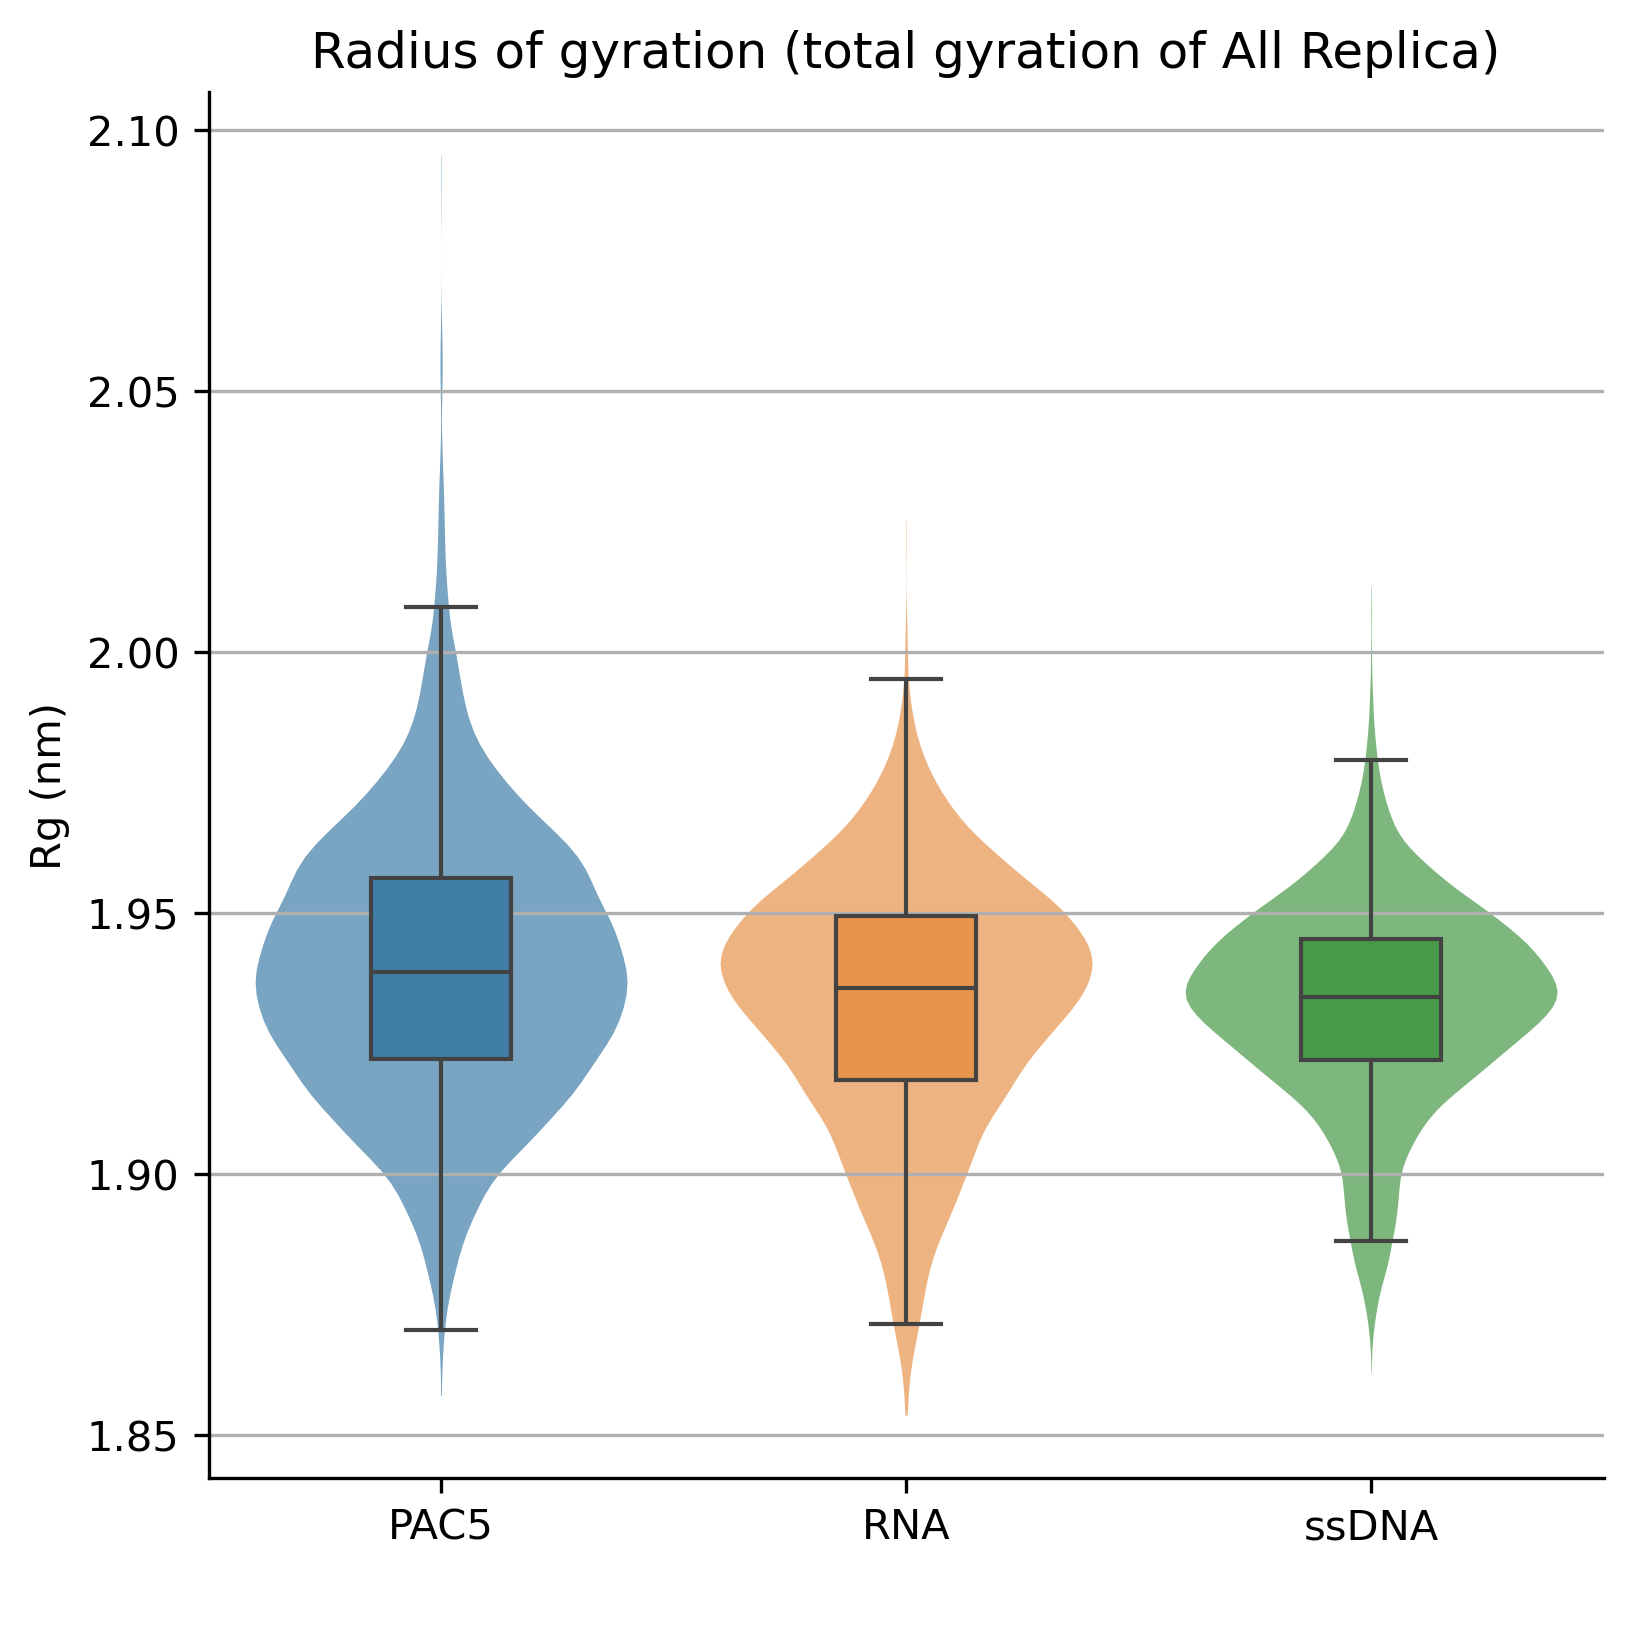

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm # type: ignore
from statsmodels.formula.api import ols # type: ignore
from statannotations.Annotator import Annotator # type: ignore

df = Gyrate_dat.copy()

# 选择需要绘制的列
columns_to_plot = ['PAC5', 'RNA', 'ssDNA']

# 将数据转换为长格式
df_long = df.melt(value_vars=columns_to_plot, var_name='Variable', value_name='Value')

PAC5_col = "#2F81B9"
RNA_col = "#FF9333"
ssDNA_col = "#3AA63A"

# 绘制小提琴图
plt.figure(figsize=(6, 6), dpi=300)
ax = sns.violinplot(
    x='Variable',
    y='Value',
    data=df_long,
    hue='Variable',  # 使用 hue 参数
    palette={'PAC5': PAC5_col, 'RNA': RNA_col, 'ssDNA': ssDNA_col},
    inner=None,  # 先不绘制内部的箱线图
    linewidth=0,
    density_norm="width",  # 使用 density_norm 参数
    cut=0,  # 控制小提琴图的尾部延伸长度
    alpha=0.7,
    legend=False  # 关闭图例
)

# 绘制箱线图
sns.boxplot(
    x='Variable',
    y='Value',
    data=df_long,
    ax=ax,
    showfliers=False,  # 不显示异常值
    linewidth=1,  # 设置箱线图的线宽
    width=0.3,  # 设置箱线图的宽度
    hue='Variable',  # 使用 hue 参数
    palette={'PAC5': PAC5_col, 'RNA': RNA_col, 'ssDNA': ssDNA_col},
    zorder=10,  # 确保箱线图在小提琴图之上
    legend=False  # 关闭图例
)

# 设置图表标题和标签
plt.title('Radius of gyration (total gyration of All Replica)')
plt.xlabel(' ')
plt.ylabel('Rg (nm)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.grid(True, axis="y")

# 进行方差分析（ANOVA）
# model = ols('Value ~ C(Variable)', data=df_long).fit()
# anova_results = sm.stats.anova_lm(model, typ=2)
# print(anova_results)

# 添加显著性标注
# pairs = [
#     ('PAC5', 'RNA'),
#     ('PAC5', 'ssDNA'),
#     ('RNA', 'ssDNA')
# ]

# annotator = Annotator(ax, pairs, data=df_long, x='Variable', y='Value')
# annotator.configure(test='t-test_ind', text_format='star', loc='inside')
# annotator.apply_and_annotate()

# 保存图表
plt.savefig("./Pics/Gyrate_ViolinBox.svg")
plt.savefig("./Pics/Gyrate_ViolinBox.png", dpi=300)

# 显示图表
plt.show()
plt.close('all')


# RMSF

In [20]:
import pandas as pd
import numpy as np

def load_mean_sd_rmsf(info_dic: dict):
    # 1. 收集 3 条曲线
    rmsf_list = []
    for key in ['RMSF_1', 'RMSF_2', 'RMSF_3']:
        fname = info_dic['paths'][key]
        # 第 0 列残基编号，第 1 列 RMSF 值
        arr = np.loadtxt(fname, comments=('#', '@'))
        resid = arr[:, 0].astype(int)
        rmsf  = arr[:, 1]
        rmsf_list.append(rmsf)

    # 2. 逐残基统计
    rmsf_mtx = np.vstack(rmsf_list)          # shape (3, n_res)
    mean = rmsf_mtx.mean(axis=0)
    std  = rmsf_mtx.std(axis=0, ddof=1)      # 样本标准差

    # 3. 打包成 DataFrame
    df = pd.DataFrame({'ResID': resid, 'mean': mean, 'std': std})
    return df.sort_values('ResID').reset_index(drop=True)

In [21]:
PAC5_info_dic = {
    "name": "PAC5",
    "paths" : {
        "RMSF_1": "../PAC5_100_1/5_RMSF/RMSF.xvg",
        "RMSF_2": "../PAC5_100_2/5_RMSF/RMSF.xvg",
        "RMSF_3": "../PAC5_500_3/5_RMSF/RMSF.xvg"
    },
    "color" : ["#2F81B9", "#2FB9A0"]
}
RNA_info_dic = {
    "name": "RNA",
    "paths" : {
        "RMSF_1": "../RNA_100_1/5_RMSF/RMSF.xvg",
        "RMSF_2": "../RNA_100_2/5_RMSF/RMSF.xvg",
        "RMSF_3": "../RNA_500_3/5_RMSF/RMSF.xvg"
    },
    "color" : ["#FF9333", "#FF4733"]
}
ssDNA_info_dic = {
    "name": "ssDNA",
    "paths" : {
        "RMSF_1": "../ssDNA_100_1/5_RMSF/RMSF.xvg",
        "RMSF_2": "../ssDNA_100_2/5_RMSF/RMSF.xvg",
        "RMSF_3": "../ssDNA_500_3/5_RMSF/RMSF.xvg"
    },
    "color" : ["#3AA63A", "#7EA63A"]
}

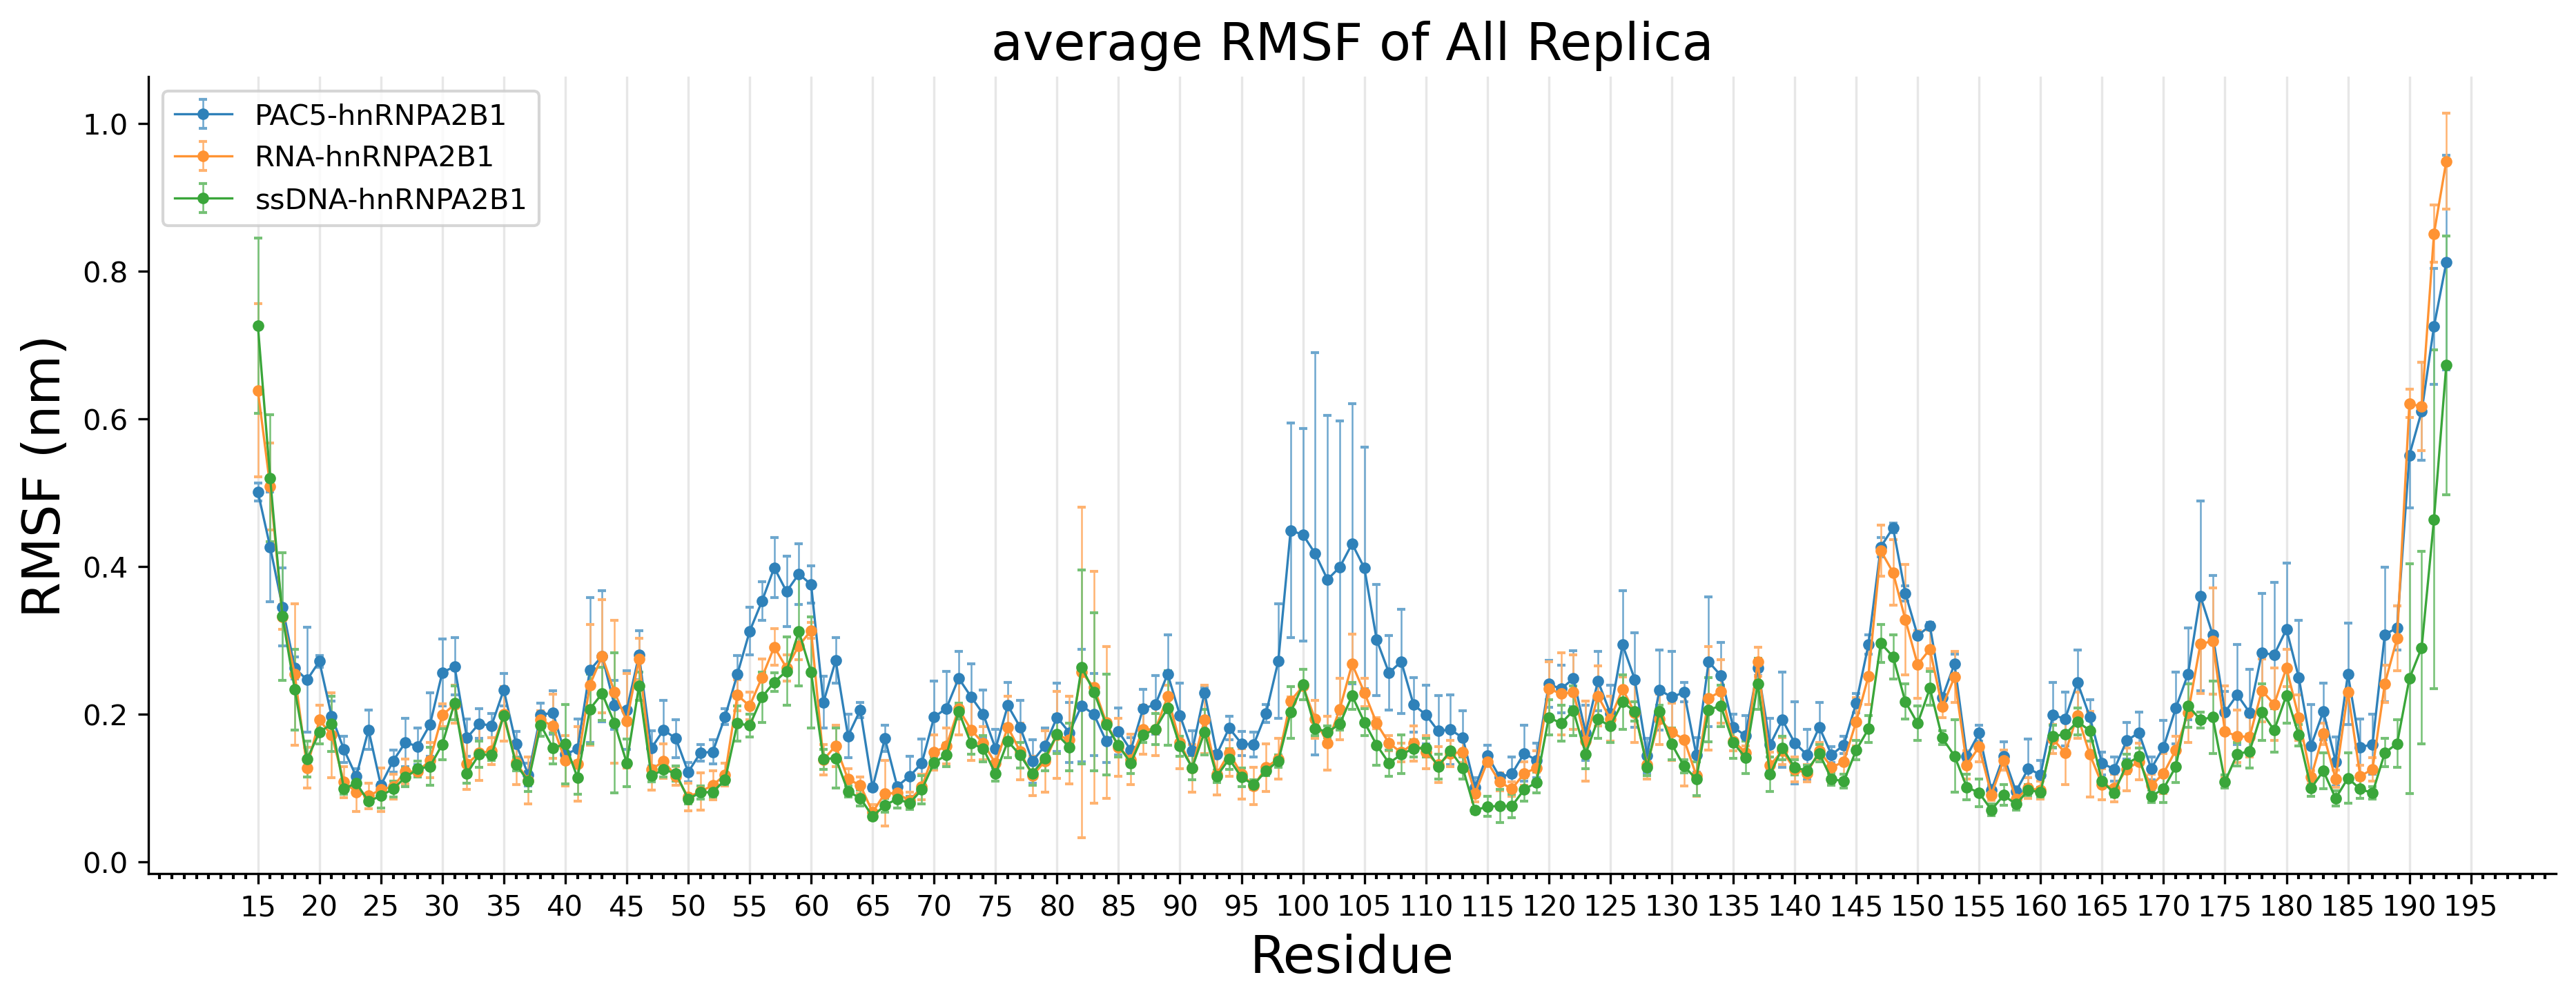

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from matplotlib import colors

# ---------- 1. 读数据 ----------
dic_list = [PAC5_info_dic, RNA_info_dic, ssDNA_info_dic]
dfs = {d['name']: load_mean_sd_rmsf(d) for d in dic_list}

# ---------- 2. 画布 ----------
fig, ax = plt.subplots(figsize=(15, 5))

# ---------- 3. 绘图 ----------
for info_dic in dic_list:
    name  = info_dic['name']
    df    = dfs[name]
    color = info_dic['color'][0]          # 主色
    # 误差棒用同系浅 30% 颜色
    ecolor = tuple(np.array(colors.to_rgb(color)) * 0.7 + 0.3)

    ax.errorbar(df['ResID'], df['mean'], yerr=df['std'],
                fmt='-', linewidth=0.8, marker='o', markersize=3,
                color=color, ecolor=ecolor, elinewidth=0.6, capsize=1.5,
                label=f'{name}-hnRNPA2B1')

# ---------- 4. 坐标轴装饰 ----------
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('average RMSF of All Replica', fontsize=18)
ax.set_xlabel('Residue', fontsize=18)
ax.set_ylabel('RMSF (nm)', fontsize=18)

# x 轴主刻度每 5 残基，次刻度每 1 残基
ax.set_xticks(np.arange(15, 200, 5))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='x', which='minor', direction='out', width=1, length=2)

ax.grid(True, axis='x', alpha=0.3)
ax.legend(loc='upper left', frameon=True)

# ---------- 5. 保存 ----------
fig.set_dpi(300)
plt.savefig("./Pics/RMSF_combine.svg", dpi=300)
plt.savefig("./Pics/RMSF_combine.png", dpi=300)
plt.show()

# MMPBSA

In [1]:
import pandas as pd
import io

def read_totals(info):
    csv_path_dic = info["paths"]
    name = info["name"]
    df_list = []
    for csv_path in csv_path_dic.values():
        with open(csv_path, 'r') as f:
            raw = f.read()
        # 2. 定位到“DELTAS: Total Energy Decomposition”这一段
        start = raw.find("Delta Energy Terms")
        block = raw[start:]
        # 3. 用 pandas 读表格
        df = pd.read_csv(
            io.StringIO(block),
            sep=',',     # 逗号或≥2个空格都当分隔符
            engine='python',
            skiprows=1,               # 跳过标题行
            header=0
        )
        df = df[["Frame #", "TOTAL"]]
        df.columns = ["Frame", name]
        df_list.append(df)
    return pd.concat(df_list)

In [2]:
PAC5_info_dic = {
    "name": "PAC5",
    "paths" : {
        "MMPBSA_1": "../PAC5_100_1/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_2": "../PAC5_100_2/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_3": "../PAC5_500_3/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv"
    },
    "color" : ["#2F81B9", "#2FB9A0"]
}
RNA_info_dic = {
    "name": "RNA",
    "paths" : {
        "MMPBSA_1": "../RNA_100_1/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_2": "../RNA_100_2/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_3": "../RNA_500_3/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv"
    },
    "color" : ["#FF9333", "#FF4733"]
}
ssDNA_info_dic = {
    "name": "ssDNA",
    "paths" : {
        "MMPBSA_1": "../ssDNA_100_1/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_2": "../ssDNA_100_2/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv",
        "MMPBSA_3": "../ssDNA_500_3/9_MMPBSA/FINAL_RESULTS_MMPBSA.csv"
    },
    "color" : ["#3AA63A", "#7EA63A"]
}

In [3]:
MMPBSA_dat = pd.merge(
    pd.merge(
        read_totals(PAC5_info_dic),
        read_totals(RNA_info_dic),
        on="Frame" ),
    read_totals(ssDNA_info_dic),
    on="Frame")
MMPBSA_dat

,Frame,PAC5,RNA,ssDNA
0,1,-22.81,-82.84,-117.57
1,1,-22.81,-82.84,-117.47
2,1,-22.81,-82.84,-117.47
3,1,-22.81,-82.84,-117.57
4,1,-22.81,-82.84,-117.47
...,...,...,...,...
31022,4997,-32.00,-89.52,-94.08
31023,4998,-21.23,-106.39,-98.75
31024,4999,-30.89,-82.58,-85.20
31025,5000,-25.77,-85.28,-97.74


In [15]:
MMPBSA_mean = MMPBSA_dat.mean()
MMPBSA_mean = pd.DataFrame(MMPBSA_dat.mean()).iloc[1:4,]
MMPBSA_mean

,0
PAC5,-21.219304
RNA,-96.294863
ssDNA,-101.748524


In [16]:
def Kd(x):
  import math
  return math.e ** (x / (0.001987*310))

MMPBSA_mean["Kd"] = MMPBSA_mean[0].apply(Kd)
MMPBSA_mean

,0,Kd
PAC5,-21.219304,1.094367e-15
RNA,-96.294863,1.278060e-68
ssDNA,-101.748524,1.825598e-72


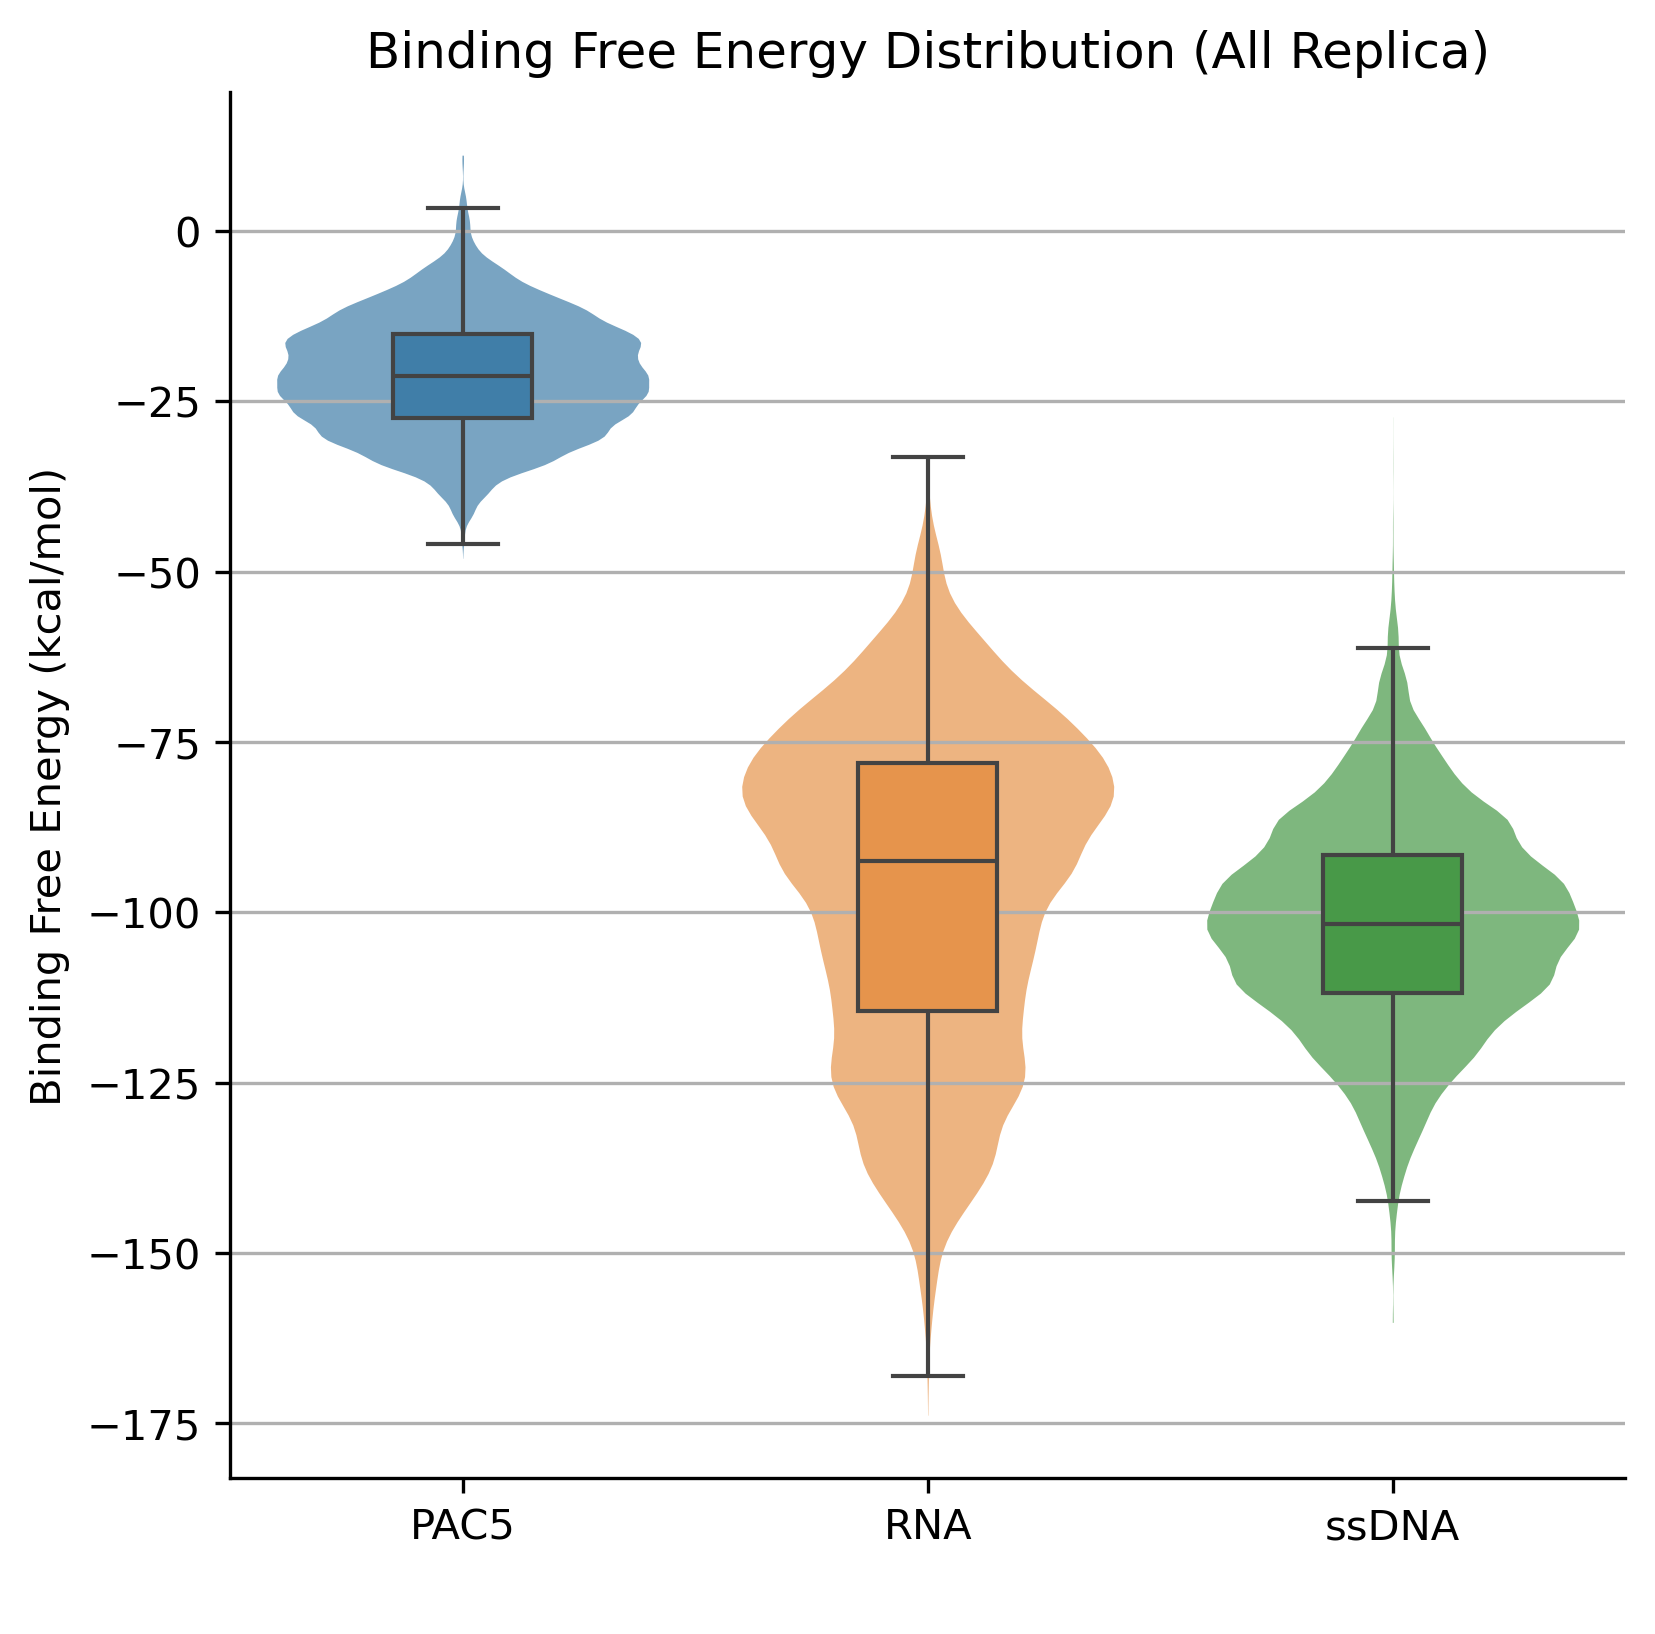

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df = MMPBSA_dat.copy()

# 选择需要绘制的列
columns_to_plot = ['PAC5', 'RNA', 'ssDNA']

# 将数据转换为长格式
df_long = df.melt(id_vars=['Frame'], value_vars=columns_to_plot, var_name='Variable', value_name='Value')

PAC5_col = "#2F81B9"
RNA_col = "#FF9333"
ssDNA_col = "#3AA63A"

# 绘制小提琴图
plt.figure(figsize=(6, 6), dpi=300)
ax = sns.violinplot(
    x='Variable',
    y='Value',
    data=df_long,
    hue='Variable',  # 使用 hue 参数
    palette={'PAC5': PAC5_col, 'RNA': RNA_col, 'ssDNA': ssDNA_col},
    inner=None,  # 先不绘制内部的箱线图
    linewidth=0,
    density_norm="width",  # 使用 density_norm 参数
    cut=0,  # 控制小提琴图的尾部延伸长度
    alpha=0.7,
    legend=False  # 关闭图例
)

# 绘制箱线图
sns.boxplot(
    x='Variable',
    y='Value',
    data=df_long,
    ax=ax,
    showfliers=False,  # 不显示异常值
    linewidth=1,  # 设置箱线图的线宽
    width=0.3,  # 设置箱线图的宽度
    hue='Variable',  # 使用 hue 参数
    palette={'PAC5': PAC5_col, 'RNA': RNA_col, 'ssDNA': ssDNA_col},
    zorder=10,  # 确保箱线图在小提琴图之上
    legend=False  # 关闭图例
)

# 设置图表标题和标签
plt.title('Binding Free Energy Distribution (All Replica)')
plt.xlabel(' ')
plt.ylabel('Binding Free Energy (kcal/mol)')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.grid(True, axis="y")

# 保存图表
plt.savefig("./Pics/MMPBSA_ViolinBox.svg")
plt.savefig("./Pics/MMPBSA_ViolinBox.png", dpi=300)

# 显示图表
plt.show()
plt.close('all')
